In [1]:
#Version Numbers Used to Generate this Pset:
#seaborn=0.11.2
#scipy==1.8.0
#numpy==1.22.2
#matplotlib==3.5.1

import scipy as sp
from pylab import *
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.ticker import MultipleLocator,FormatStrFormatter,MaxNLocator
import pandas as pd
import seaborn as sns
import collections
from IPython.display import clear_output
import random
import openpyxl
import os 
sns.set_style("ticks")
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, explained_variance_score, r2_score
from sklearn.preprocessing import PolynomialFeatures
import pickle
from matplotlib.colors import LogNorm  # Import LogNorm for logarithmic color scale

DataTitle="Data_dynamics"

np.random.seed(1)
if not os.path.exists(DataTitle):

   # Create a new directory because it does not exist
   os.makedirs(DataTitle)
   print("The new directory is created!")

mm = 0.1/2.54
os.environ['PATH'] = os.environ['PATH'] + ':/Library/TeX/texbin/latex'
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['figure.dpi'] = 600
mpl.rcParams['font.size'] = 8
mpl.rcParams['axes.linewidth'] = 0.5
mpl.rcParams['xtick.minor.width'] = 0.4
mpl.rcParams['xtick.major.width'] = 0.5
mpl.rcParams['ytick.minor.width'] = 0.4
mpl.rcParams['ytick.major.width'] = 0.5

plt.rcParams['text.usetex'] = False
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

sns.color_palette("tab10")

[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
 (0.4980392156862745, 0.4980392156862745, 0.4980392156862745),
 (0.7372549019607844, 0.7411764705882353, 0.13333333333333333),
 (0.09019607843137255, 0.7450980392156863, 0.8117647058823529)]

In [2]:
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

my_cmap = ListedColormap(['#00429d', '#4771b2', '#73a2c6', '#a5d5d8', '#ffffe0', '#ffbcaf', '#f4777f', '#cf3759', '#93003a'], name="my_cmap")
my_cmap_r = my_cmap.reversed()
mpl.colormaps.register(cmap=my_cmap)
mpl.colormaps.register(cmap=my_cmap_r)

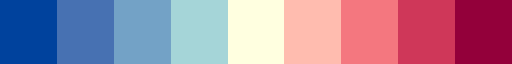

In [3]:
my_cmap

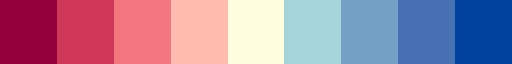

In [4]:
my_cmap_r

In [5]:
def getIDX(data, IDX):
    O = np.flatnonzero([x == IDX for x in data['SampleIDX']])
    return np.array(O)

def getAbundance(Processed_sequences,IDX):
    SampleIdx= np.flatnonzero([x == IDX for x in Processed_sequences['SampleIDX']])
    if not any(SampleIdx):
        return
    else:
        O=Processed_sequences.iloc[SampleIdx].values.tolist()[0][1:]
        return O

def getAbundance_fromList(Processed_sequences,IDX_list):
    IDX_list_=np.squeeze([np.where(Processed_sequences['SampleIDX']==x) for x in IDX_list])
    return (np.array(Processed_sequences.iloc[IDX_list_].values)[:,1:]).astype(float)

def Community_PermutateList_simulation(I,S):
    global Metadata,exception_list
    sample_num=100
    O=(3*(I-1)+(S-1))*100+np.arange(0,100)
    return O

def CommunityPermutate(Timepoint, CommunityOrigin, Medium, CoalescenceType):
    global Metadata
    idx = np.where((Metadata['Timepoint'] == Timepoint) &
                   (Metadata['CommunityOrigin'] == CommunityOrigin) &
                   (Metadata['Medium'] == Medium) &
                   (Metadata['CoalescenceType'] == CoalescenceType))[0]
    O = np.concatenate(Metadata['SampleIDX'][idx])
    return O

def CommunityPermutate_withSpeciesPoolsize(Timepoint, CommunityOrigin, Medium, CoalescenceType, species_pool_num):
    global Metadata,exception_list
    idx = (Metadata['Timepoint'] == Timepoint) & \
          (Metadata['CommunityOrigin'] == CommunityOrigin) & \
          (Metadata['Medium'] == Medium) & \
          (Metadata['CoalescenceType'] == CoalescenceType)

    communityIDX = np.array([int(x) for x in Metadata['CommunityIDX']])
    if CoalescenceType == 'S':
        if species_pool_num == 6:
            idx = idx & (communityIDX <= 9)
        elif species_pool_num == 12:
            idx = idx & ((communityIDX > 9) & (communityIDX <= 18))
        elif species_pool_num == 24:
            idx = idx & ((communityIDX > 18) & (communityIDX <= 30))
    elif CoalescenceType == 'C':
        if species_pool_num == 6:
            idx = idx & (communityIDX <= 14)
        elif species_pool_num == 12:
            idx = idx & ((communityIDX > 14) & (communityIDX <= 41))
        elif species_pool_num == 24:
            idx = idx & ((communityIDX > 41) & (communityIDX <= 47))

    O = Metadata['SampleIDX'][idx]
    O = list(set(O) - set(exception_list))
    return O

def Community_PermutateList(Timepoint, CommunityOrigin, Medium, CoalescenceType, species_pool_num=0, Replicate=-1):
    global Metadata,exception_list
    
    if Replicate==-1:
        idx = (Metadata['Timepoint'] == Timepoint) & \
              (Metadata['CommunityOrigin'] == CommunityOrigin) & \
              (Metadata['Medium'] == Medium) & \
              (Metadata['CoalescenceType'] == CoalescenceType)
    elif Replicate == 1 or Replicate == 2 : 
        idx = (Metadata['Timepoint'] == Timepoint) & \
              (Metadata['CommunityOrigin'] == CommunityOrigin) & \
              (Metadata['Medium'] == Medium) & \
              (Metadata['CoalescenceType'] == CoalescenceType) & \
              (Metadata['Replicate'] == Replicate)
    else : 
        raise ValueError("Invalid input")

    
    if CommunityOrigin=='S':
        communityIDX = np.array([int(x) for x in Metadata['CommunityIDX']])
        if CoalescenceType == 'S':
            if species_pool_num == 6:
                idx = idx & (communityIDX <= 9)
            elif species_pool_num == 12:
                idx = idx & ((communityIDX > 9) & (communityIDX <= 18))
            elif species_pool_num == 24:
                idx = idx & ((communityIDX > 18) & (communityIDX <= 30))
            elif species_pool_num ==0:
                idx = idx
        elif CoalescenceType == 'C':
            if species_pool_num == 6:
                idx = idx & (communityIDX <= 14)
            elif species_pool_num == 12:
                idx = idx & ((communityIDX > 14) & (communityIDX <= 41))
            elif species_pool_num == 24:
                idx = idx & ((communityIDX > 41) & (communityIDX <= 47))
            elif species_pool_num ==0:
                idx = idx
    elif CommunityOrigin=='N':
        communityIDX = np.array([int(x) for x in Metadata['CommunityIDX']])
        
    O = Metadata['SampleIDX'][idx]
    O = list(set(O) - set(exception_list))
    return O

def getCommunities(Communities_data,IDX_list):
    IDX_list_=np.squeeze([np.where(Communities_data['SampleIDX']==x) for x in IDX_list])
    return (Communities_data.iloc[IDX_list_])

def getCoalescence(Coalescence_data,IDX_list):
    IDX_list_=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])#IDX_list_
    return (Coalescence_data.iloc[IDX_list_])

Coalescence_data_synthetic_path ="../../Analyzed/processed_CoalescenceEvent_synthetic.xlsx"
Communities_data_synthetic_path ="../../Analyzed/processed_Communities_synthetic.xlsx"
Coalescence_data_natural_path ="../../Analyzed/processed_CoalescenceEvent_natural.xlsx"
Communities_data_natural_path ="../../Analyzed/processed_Communities_natural.xlsx"
Coalescence_recipe_path="../../Postprocessed/CoalescenceRecipe.xlsx"
Meta_data_path="../../Postprocessed/Metadata.xlsx"
Processed_sequences_synthetic_path="../../Postprocessed/processed_Sequences_synthetic.xlsx"
Processed_sequences_natural_path="../../Postprocessed/processed_Sequences_natural.xlsx"
Coalescence_data_sim_path="../../Analyzed/processed_CoalescenceEvent_simulation_uniform.xlsx"
#Communities_data_sim_path="Analyzed/processed_Communities_simulation_uniform.xlsx"

Coalescence_data=pd.concat([pd.read_excel(Coalescence_data_synthetic_path),pd.read_excel(Coalescence_data_natural_path)])
Communities_data=pd.concat([pd.read_excel(Communities_data_synthetic_path),pd.read_excel(Communities_data_natural_path)])
Coalescence_data_sim=pd.read_excel(Coalescence_data_sim_path)
#Communities_data_sim=pd.read_excel(Communities_data_sim_path)

Coalescence_recipe=pd.read_excel(Coalescence_recipe_path,sheet_name=0)
Coalescence_natural_recipe=pd.read_excel(Coalescence_recipe_path,sheet_name=1)
Metadata=pd.read_excel(Meta_data_path)
Processed_sequences_synthetic=pd.read_excel(Processed_sequences_synthetic_path)
Processed_sequences_natural=pd.read_excel(Processed_sequences_natural_path)

exception_list=['P4-02','P4-03','P4-23','P4-24','P7-97', 'P8-12']+['P8-91'] + ['P5-73', 'P5-69','P5-64','P5-61','P5-59', 'P5-56'] + ['P5-47', 'P5-50'] + ['P5-39', 'P5-87', 'P5-54', 'P6-02', 'P6-47', 'P6-74', 'P6-57']
#'P4-02','P4-03','P4-23','P4-24','P7-97', 'P8-12' : These cases are for no reads in coalescence result
# 'P8-91' : no file
#['P5-73', 'P5-69','P5-64','P5-61','P5-59', 'P5-56'] : MN E7 is missing
# 'P6-67' : is too low reads( 500)
# 'P5-47', 'P5-50' : MN24 CC, too much unwanted ASVs(maybe due to wrong labeling)
# ['P5-39', 'P5-87', 'P5-54', 'P6-02', 'P6-47', 'P6-74', 'P6-57'] : ASV not in sub 2> 0.3

I = [0.33, 0.66, 0.99]
species_pools = [6, 12, 24]
sample_num=100
Syn_Simulation_IDX = {
    "I1_S1": Community_PermutateList_simulation(1,1),
    "I1_S2": Community_PermutateList_simulation(1,2),
    "I1_S3": Community_PermutateList_simulation(1,3),
    "I2_S1": Community_PermutateList_simulation(2,1),
    "I2_S2": Community_PermutateList_simulation(2,2),
    "I2_S3": Community_PermutateList_simulation(2,3),
    "I3_S1": Community_PermutateList_simulation(3,1),
    "I3_S2": Community_PermutateList_simulation(3,2),
    "I3_S3": Community_PermutateList_simulation(3,3),
}
mediums_pools = ["LN", "MN", "HN"]
species_pools = [6, 12, 24]
Syn_Coal_IDX = {
    "LN_6": Community_PermutateList("F", "S", "L", "C", 6),
    "LN_12": Community_PermutateList("F", "S", "L", "C", 12),
    "LN_24": Community_PermutateList("F", "S", "L", "C", 24),
    "MN_6": Community_PermutateList("F", "S", "M", "C", 6),
    "MN_12": Community_PermutateList("F", "S", "M", "C", 12),
    "MN_24": Community_PermutateList("F", "S", "M", "C", 24),
    "HN_6": Community_PermutateList("F", "S", "H", "C", 6),
    "HN_12": Community_PermutateList("F", "S", "H", "C", 12),
    "HN_24": Community_PermutateList("F", "S", "H", "C", 24)
}
Syn_Sub_IDX = {
    "LN_6": Community_PermutateList("F", "S", "L", "S", 6),
    "LN_12": Community_PermutateList("F", "S", "L", "S", 12),
    "LN_24": Community_PermutateList("F", "S", "L", "S", 24),
    "MN_6": Community_PermutateList("F", "S", "M", "S", 6),
    "MN_12": Community_PermutateList("F", "S", "M", "S", 12),
    "MN_24": Community_PermutateList("F", "S", "M", "S", 24),
    "HN_6": Community_PermutateList("F", "S", "H", "S", 6),
    "HN_12": Community_PermutateList("F", "S", "H", "S", 12),
    "HN_24": Community_PermutateList("F", "S", "H", "S", 24)
}
Nat_Coal_IDX = {
    "LN": Community_PermutateList("F", "N", "L", "C"),
    "MN": Community_PermutateList("F", "N", "M", "C"),
    "HN": Community_PermutateList("F", "N", "H", "C")
}
Nat_Sub_IDX = {
    "LN": Community_PermutateList("F", "N", "L", "S"),
    "MN": Community_PermutateList("F", "N", "M", "S"),
    "HN": Community_PermutateList("F", "N", "H", "S")
}




In [6]:
from InitializeSpeciesPool import *
from LV import *
from VariousMetrics import *

########################################################
########################################################
# Fig 3-1
########################################################
########################################################

##~~~~~~~~~~~~~~ This figure is cartoon ~~~~~~~~~~~~~~##

In [7]:
def pHcriteria(pH_list,return_type="Num"):
    pH_list=np.array(pH_list)
    O=1*(pH_list>6)+1*(pH_list>8)
    if return_type=="Num":
        return O
    if return_type=="Word":
        word_list=['acidic','neutral','alkalic']
        return [word_list[x] for x in O]
    if return_type=="Color":
        word_list=['r','g','b']
        return [word_list[x] for x in O]

def getDominanceMatrix(Variable2plot, Coalescence_data, Coal_IDX_list, Sub_IDX_list):
    N=len(Sub_IDX_list)
    matrix={Sub_IDX : {} for Sub_IDX in Sub_IDX_list }
    for SampleIDX in Coal_IDX_list:
        idx=np.where(Coalescence_data['SampleIDX']==SampleIDX)
        dominance1=Coalescence_data.iloc[idx][Variable2plot].tolist()[0]
        dominance2=1-dominance1
        subSampleIDX1=Coalescence_data.iloc[idx]["SampleIDX_Sub1"].tolist()[0]
        #subidx1=np.where(Sub_IDX_list==subSmapleIDX1)
        subSampleIDX2=Coalescence_data.iloc[idx]["SampleIDX_Sub2"].tolist()[0]


        #subidx2=np.where(Sub_IDX_list==subSmapleIDX2)
        matrix[subSampleIDX1].update({subSampleIDX2:dominance1})
        matrix[subSampleIDX2].update({subSampleIDX1:dominance2})
    for SampleIDX in Sub_IDX_list:
        matrix[SampleIDX].update({SampleIDX:0.5})
    
    return matrix   

def EstimateErrorLassoRegression2(matrix, order, alpha, beta, preprocess='Normalize', verbose=False):
    train_mse_list=[]
    test_mse_list=[]
    IDX_list1=[]
    IDX_list2=[]
    x=[]
    y=[]
    for i,C_1 in enumerate(matrix):
        for j,C_2 in enumerate(matrix[C_1]):
            IDX_list1.append(C_1)
            IDX_list2.append(C_2)
            y.append(matrix[C_1][C_2])
    y=np.array(y)
    x=np.array(getAbundance_fromList(Processed_sequences_synthetic,IDX_list1))-np.array(getAbundance_fromList(Processed_sequences_synthetic,IDX_list2))

    if preprocess=='Basic':
        y_tofit=y.copy()
    elif preprocess=='Normalize':
        y_tofit=(y.copy()-0.5)*2
    elif preprocess=='Tan':
        y_tofit=np.tan((y.copy()-0.5)*np.pi/2)
    
    fig=plt.figure(figsize=(70*mm,60*mm))
    
    for i, (IDX1, IDX2) in enumerate(zip(IDX_list1, IDX_list2)):
        if IDX1==IDX2:
            continue
        community_IDX1=np.unique(getCommunities(Communities_data,[IDX1])['CommunityIDX'])[0]
        community_IDX2=np.unique(getCommunities(Communities_data,[IDX2])['CommunityIDX'])[0]
        print(community_IDX1,community_IDX2)
        
        #ToTestIndex=(getCommunities(Communities_data,IDX_list1)['CommunityIDX']==community_IDX1) & (getCommunities(Communities_data,IDX_list2)['CommunityIDX']==community_IDX2)
        print(np.where(getCommunities(Communities_data,IDX_list1)['CommunityIDX']==community_IDX1))
        print(np.where(getCommunities(Communities_data,IDX_list2)['CommunityIDX']==community_IDX2))


        '''
        train_idx_list=np.where(~ToTestIndex)[0]
        test_idx_list=np.where(ToTestIndex)[0]

        # Generate synthetic data
        X_train = beta*x[train_idx_list,:]
        y_train = y_tofit[train_idx_list]#y[:]
        X_test = beta*x[test_idx_list,:]
        y_test = y_tofit[test_idx_list]
        # Split data into training and testing sets
        
        # Transform features to include up to second-order terms
        polynomial_features = PolynomialFeatures(degree=order, include_bias=True)
        X_train_poly = polynomial_features.fit_transform(X_train)
        X_test_poly = polynomial_features.transform(X_test)

        # Create the model
        model = Lasso(alpha=alpha, max_iter = 1000)

        # Fit the model to the training data
        model.fit(X_train_poly, y_train)

        # Predict the target values for the test set
        y_pred_train = model.predict(X_train_poly)
        y_pred_test = model.predict(X_test_poly)

        # Evaluate the model
        train_mse = np.mean((y_train-y_pred_train)**2)
        test_mse = np.mean((y_test-y_pred_test)**2)
        ref_mse= np.var(y_tofit)
        if verbose:
            print(f'Mean Train Squared Error: {train_mse}')
            print(f'Mean Test Squared Error: {test_mse, y_test, y_pred_test}')
        plt.scatter(y_test,y_pred_test)
        train_mse_list.append(train_mse/ref_mse)
        test_mse_list.append(test_mse/ref_mse)
    
    range_min=min(plt.xlim()[0],plt.ylim()[0])
    range_max=max(plt.xlim()[1],plt.ylim()[1])
    plt.plot([range_min, range_max],  [range_min,range_max], color='r')
    print([range_min, range_max],  [range_min,range_max])
    plt.text(range_max, range_max, f'Error={mean(test_mse_list)}',color='r', fontsize=6)
    if True:
        getCommunities(Communities_data,Community_PermutateList("F", com_type, medium, "S", species_num, rep))
        train_idx_list=np.where(getCommunities(Communities_data,IDX_list)['CommunityIDX'])[0]
        test_idx_list=[]

        # Generate synthetic data
        X_train = beta*x[train_idx_list,:]
        y_train = y_tofit[train_idx_list]#y[:]
        X_test = beta*x[test_idx_list,:]
        y_test = y_tofit[test_idx_list]
        # Split data into training and testing sets
        
        # Transform features to include up to second-order terms
        polynomial_features = PolynomialFeatures(degree=order, include_bias=True)
        X_train_poly = polynomial_features.fit_transform(X_train)
        #X_test_poly = polynomial_features.transform(X_test)

        # Create the model
        model = Lasso(alpha=alpha, max_iter = 1000)

        # Fit the model to the training data
        model.fit(X_train_poly, y_train)
        '''
        
    return communityIDX_list, train_mse_list, test_mse_list ,model, polynomial_features
    

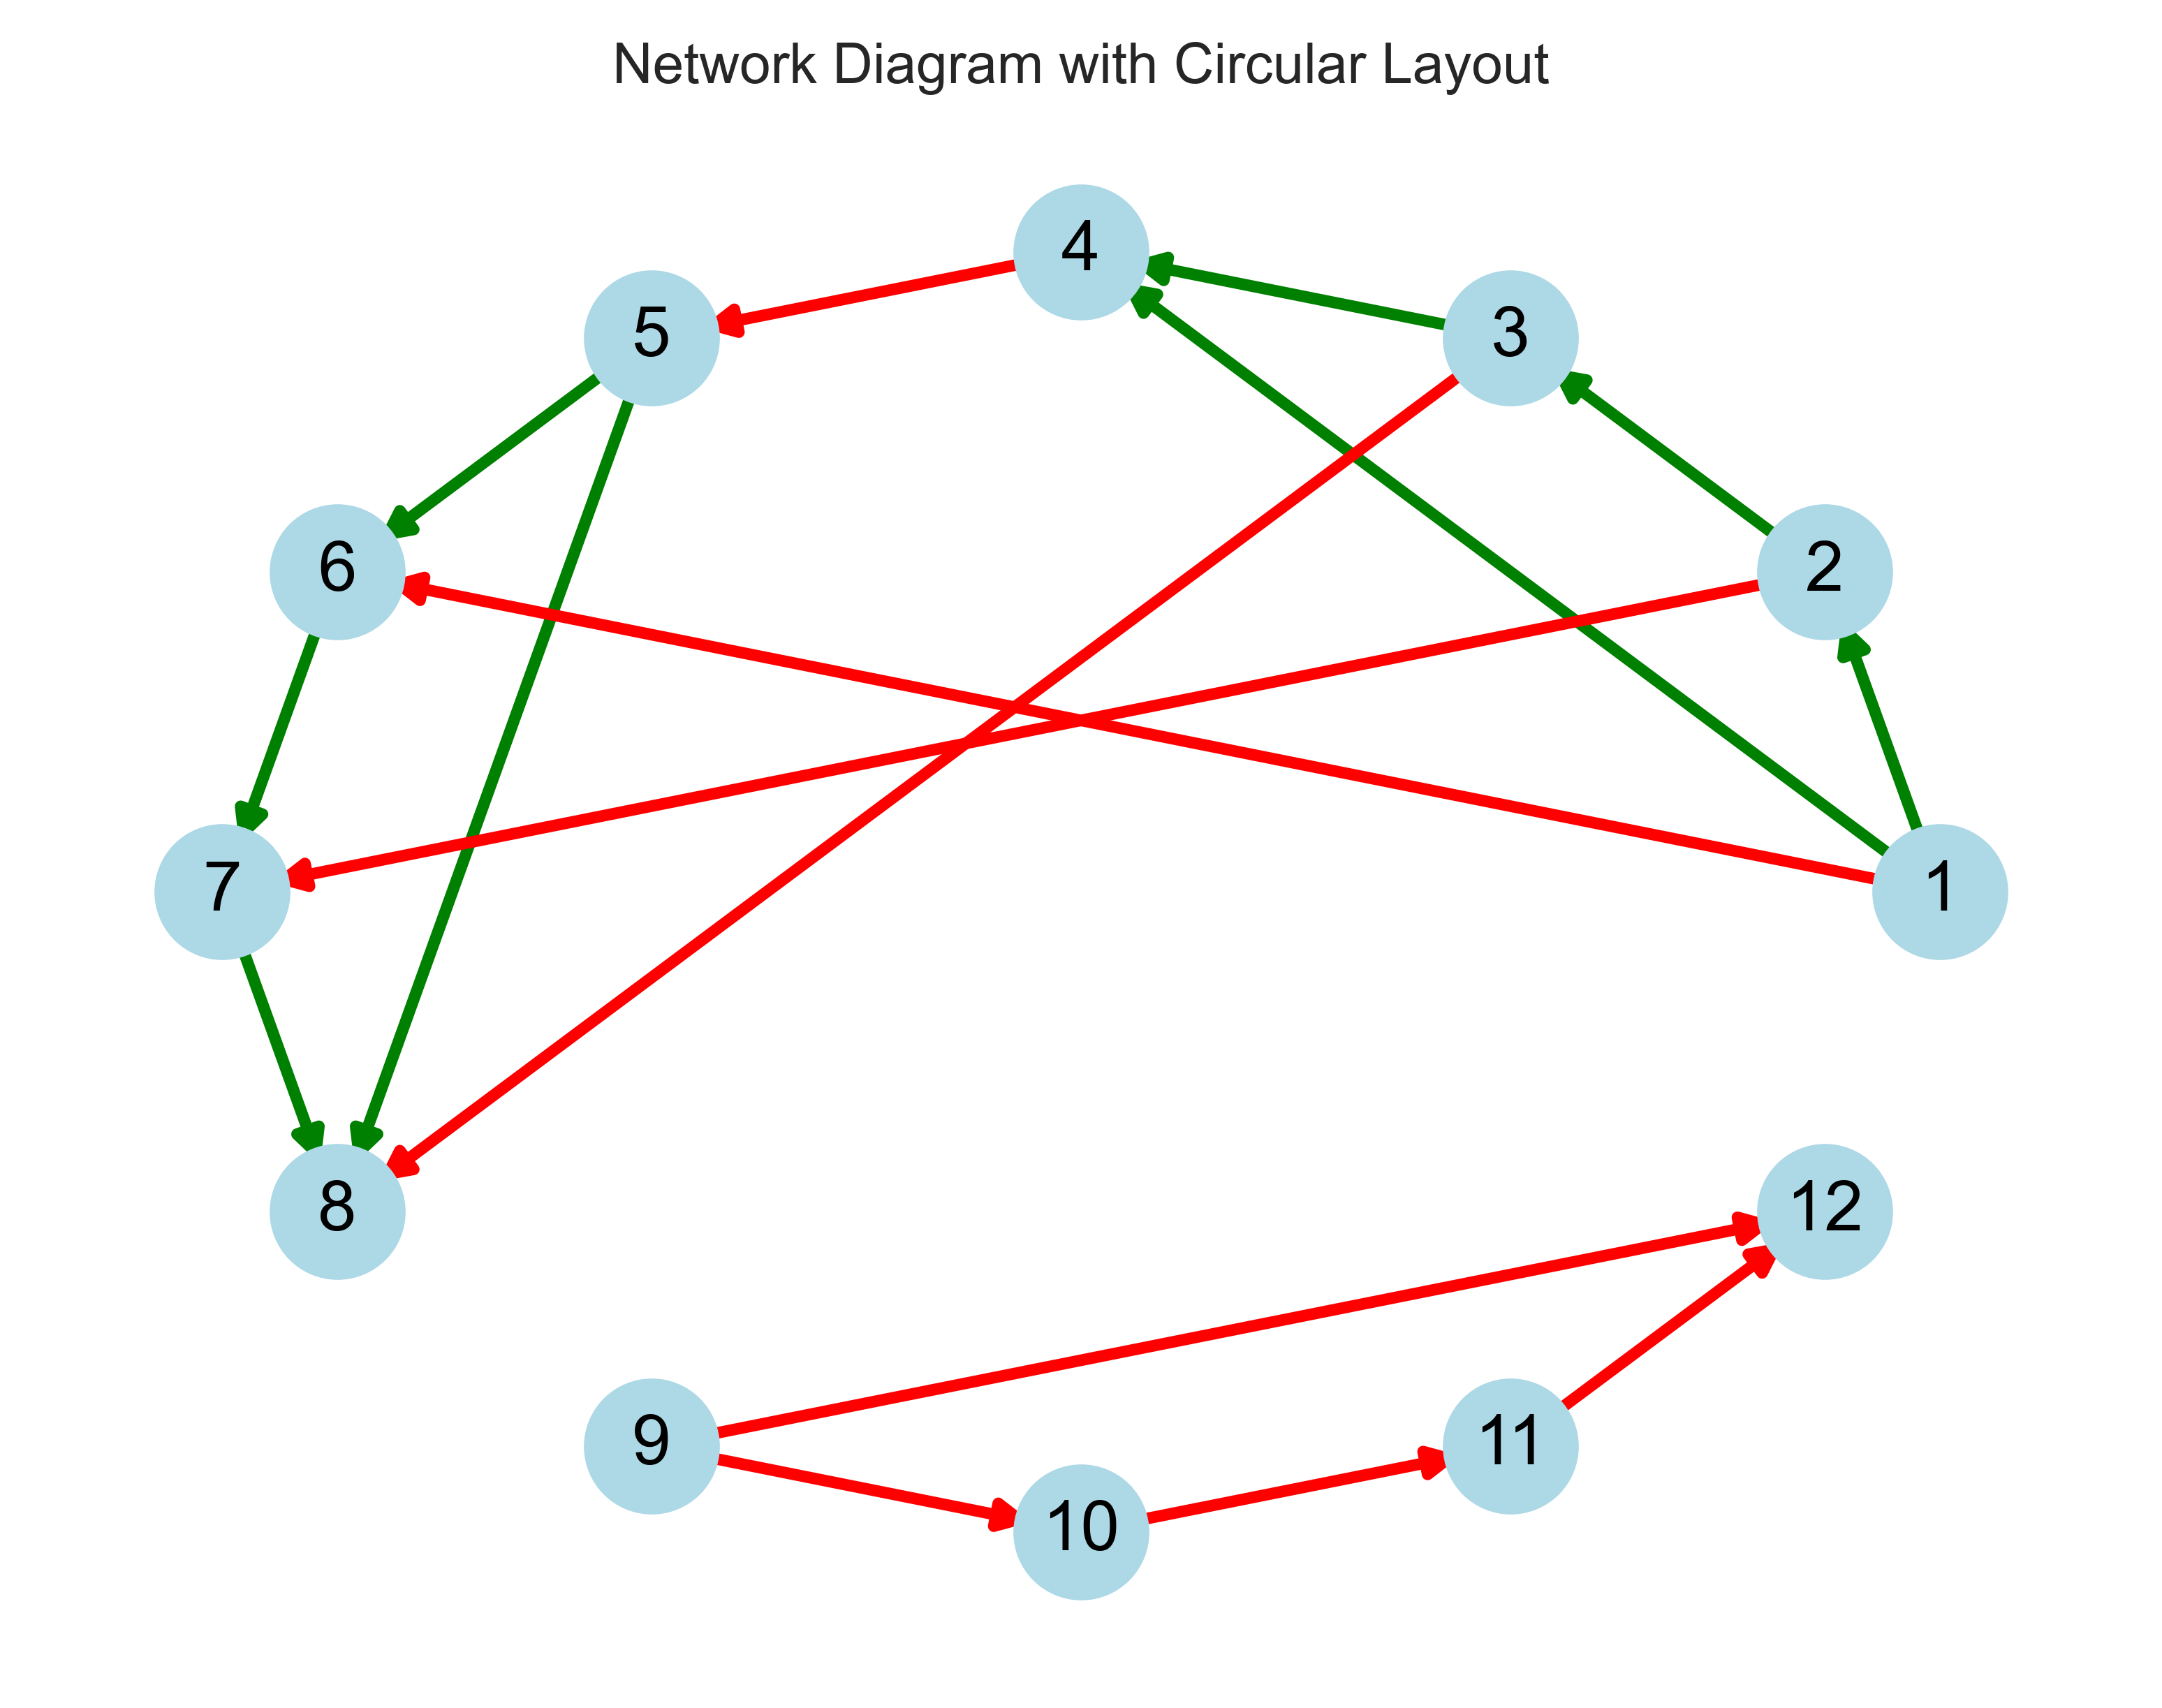

In [8]:
import networkx as nx

# Create an empty graph
G = nx.Graph()

# Add 12 nodes
num_nodes = 12
for i in range(num_nodes):
    G.add_node(i)

# Define your positive and negative edges
positive_edges = [(0, 1), (1, 2), (2, 3), (3, 0), (4, 5), (5, 6), (6, 7), (7, 4)]
negative_edges = [(0, 5), (1, 6), (2, 7), (3, 4), (8, 9), (9, 10), (10, 11), (11, 8)]

# Add edges to the graph
G.add_edges_from(positive_edges, sign='positive')
G.add_edges_from(negative_edges, sign='negative')


pos = nx.circular_layout(G)




# Separate edges based on their sign
positive_edges = [(u, v) for u, v, d in G.edges(data=True) if d['sign'] == 'positive']
negative_edges = [(u, v) for u, v, d in G.edges(data=True) if d['sign'] == 'negative']

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=500, node_color='lightblue')

# Draw positive edges in green and negative edges in red
nx.draw_networkx_edges(G, pos, edgelist=positive_edges, edge_color='green', width=2, arrows=True)
nx.draw_networkx_edges(G, pos, edgelist=negative_edges, edge_color='red', width=2, arrows=True)

# Add labels to nodes (optional)
labels = {i: i + 1 for i in range(num_nodes)}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=12)

# Remove axis
plt.axis('off')

# Show the plot
plt.title("Network Diagram with Circular Layout")
plt.show()


In [9]:
Pairwise_Count_data_path="../../Postprocessed/PairwiseColonyCountings_processed_230915.xlsx"

Mono_Count_data={}
Pairwise_Count_data={}

Data=pd.read_excel(Pairwise_Count_data_path, sheet_name=0)
Data=np.transpose(np.array(Data.values[:,1:]))
Mono_Count_data["LN"]=Data
Data=pd.read_excel(Pairwise_Count_data_path, sheet_name=1)
Data=np.transpose(np.array(Data.values[:,1:]))
Mono_Count_data["MN"]=Data
Data=pd.read_excel(Pairwise_Count_data_path, sheet_name=2)
Data=np.transpose(np.array(Data.values[:,1:]))
Mono_Count_data["HN"]=Data
Data=pd.read_excel(Pairwise_Count_data_path, sheet_name=3)
Data=np.array(Data.values[:,1:])
Data_1=Data #This is the species for the first index
Data=pd.read_excel(Pairwise_Count_data_path, sheet_name=4)
Data=np.array(Data.values[:,1:])
Data_2=Data #This is the species for the second index
Data=np.stack([Data_1,Data_2])
Pairwise_Count_data["LN"]=Data

Data=pd.read_excel(Pairwise_Count_data_path, sheet_name=5)
Data=np.array(Data.values[:,1:])
Data_1=Data #This is the species for the first index
Data=pd.read_excel(Pairwise_Count_data_path, sheet_name=6)
Data=np.array(Data.values[:,1:])
Data_2=Data #This is the species for the second index
Data=np.stack([Data_1,Data_2])
Pairwise_Count_data["MN"]=Data

Data=pd.read_excel(Pairwise_Count_data_path, sheet_name=7)
Data=np.array(Data.values[:,1:])
Data_1=Data #This is the species for the first index
Data=pd.read_excel(Pairwise_Count_data_path, sheet_name=8)
Data=np.array(Data.values[:,1:])
Data_2=Data #This is the species for the second index
Data=np.stack([Data_1,Data_2])
Pairwise_Count_data["HN"]=Data

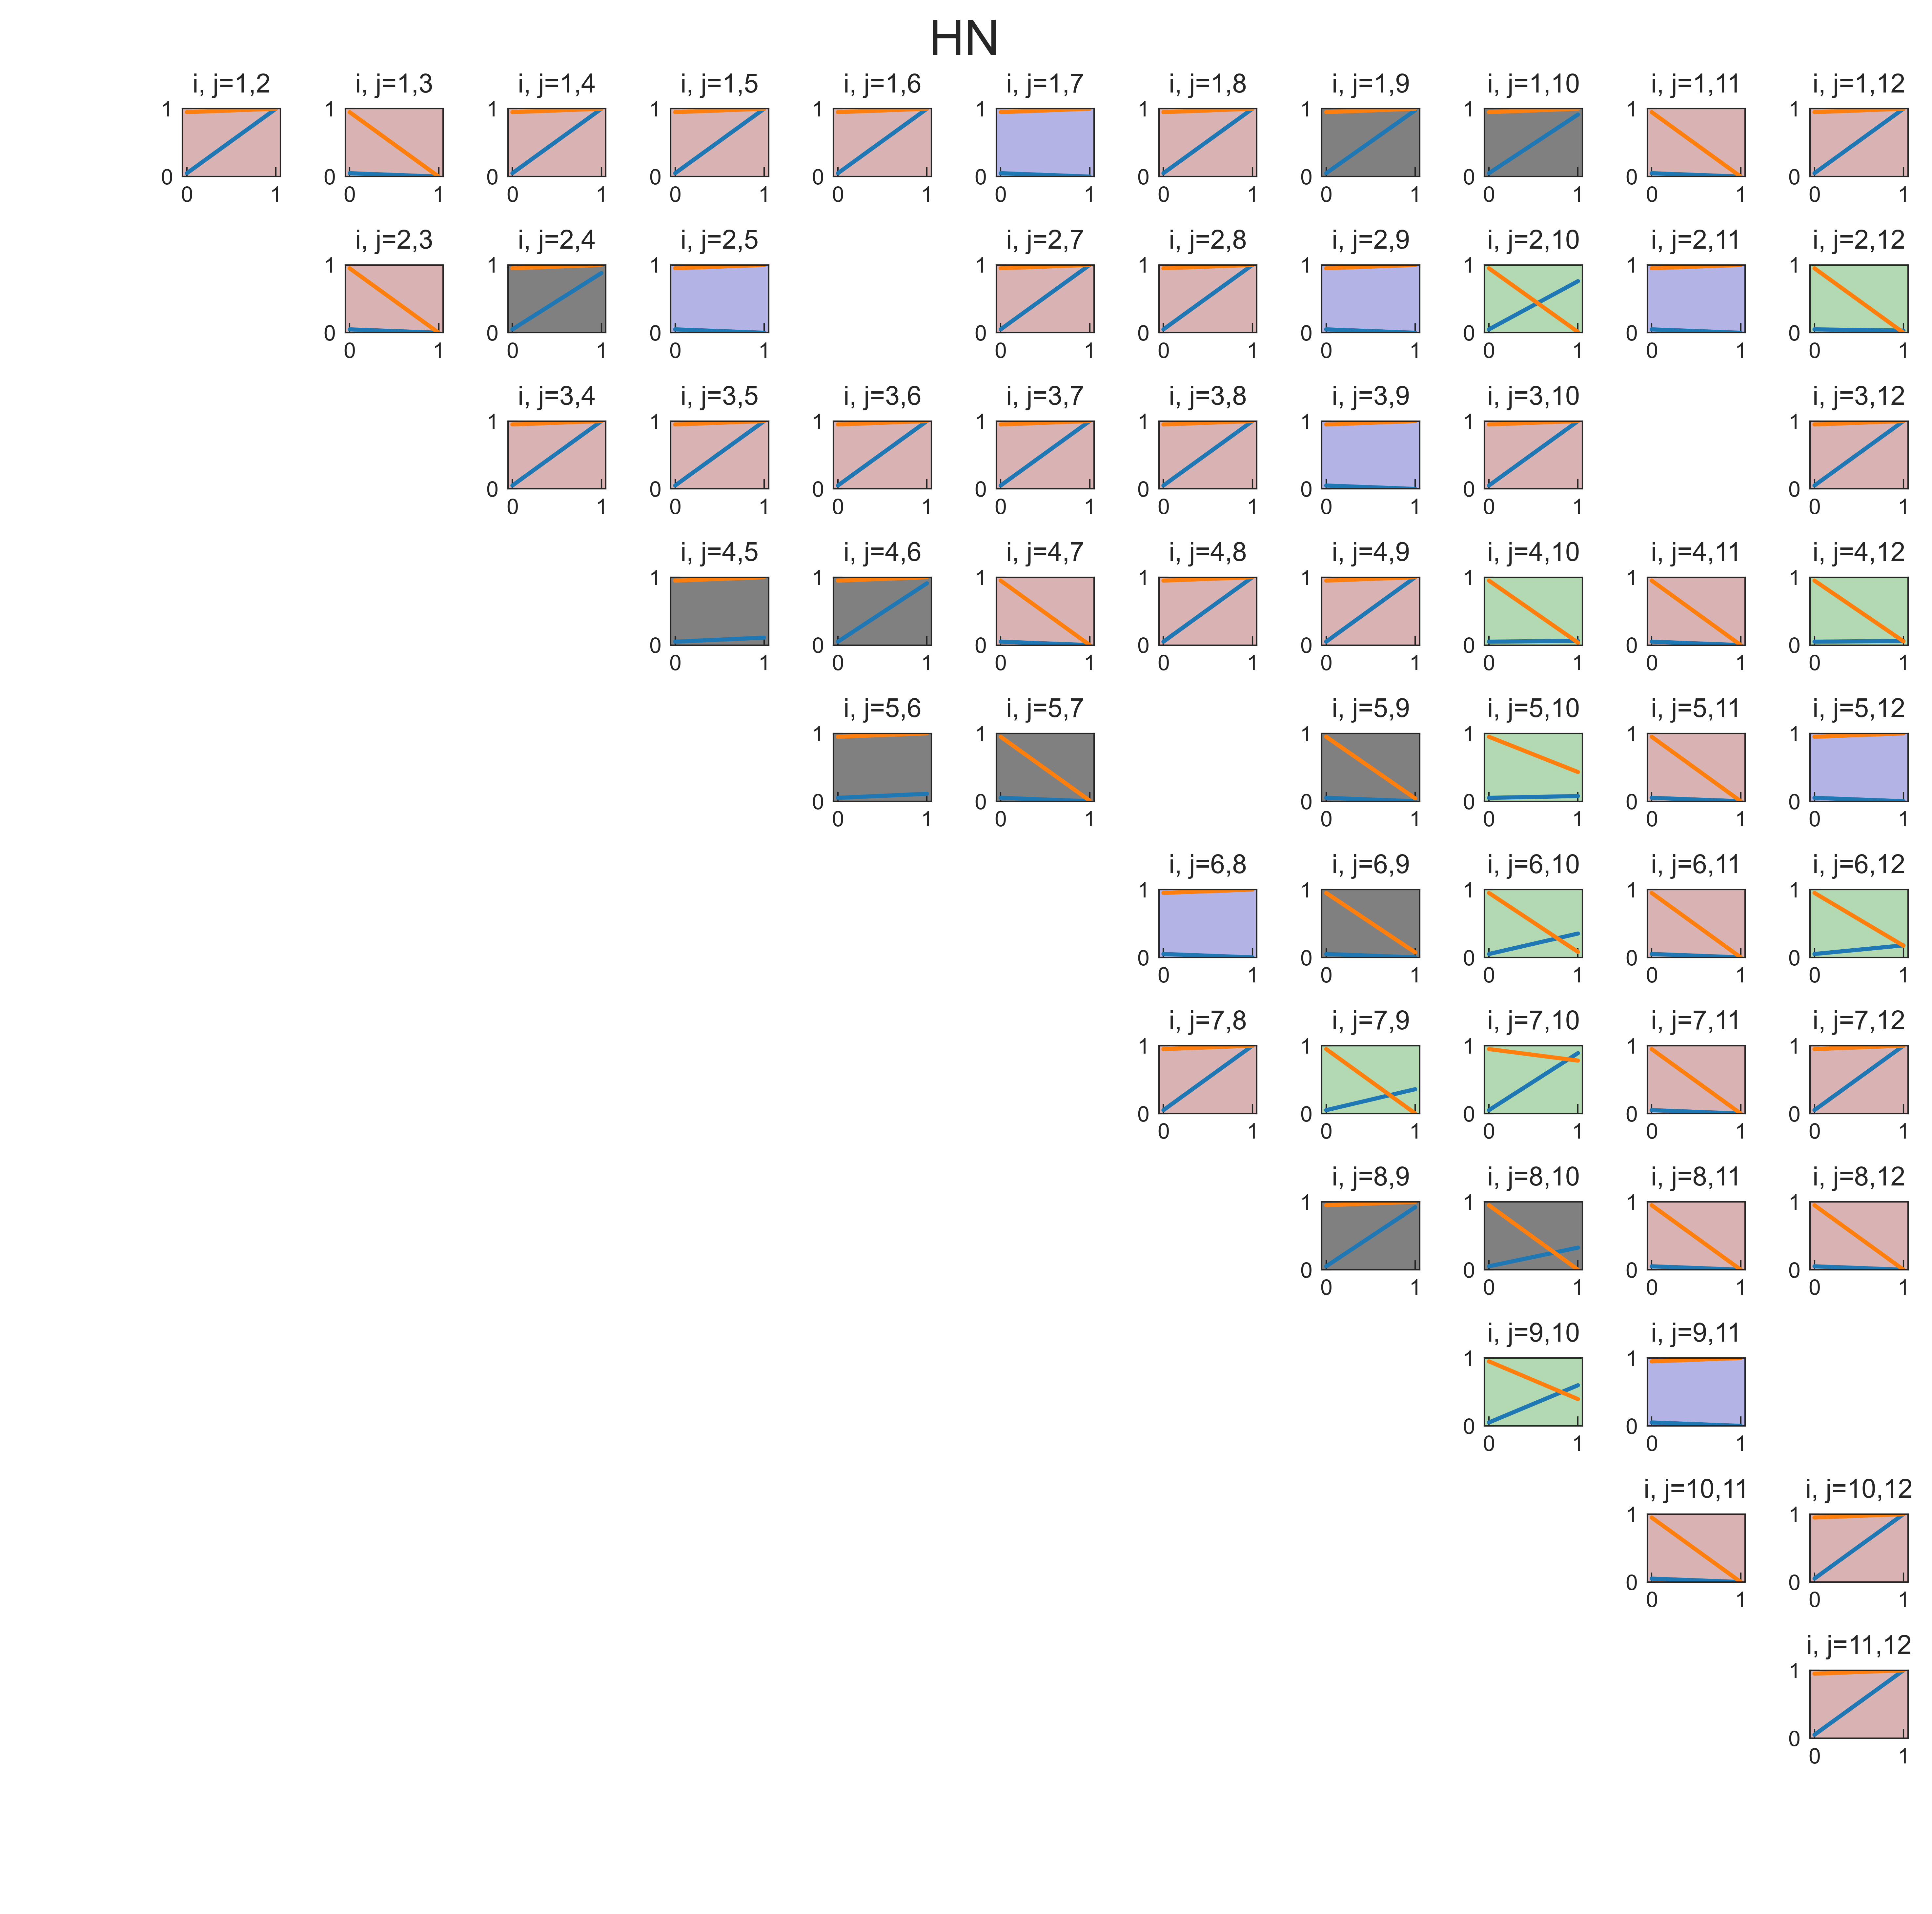

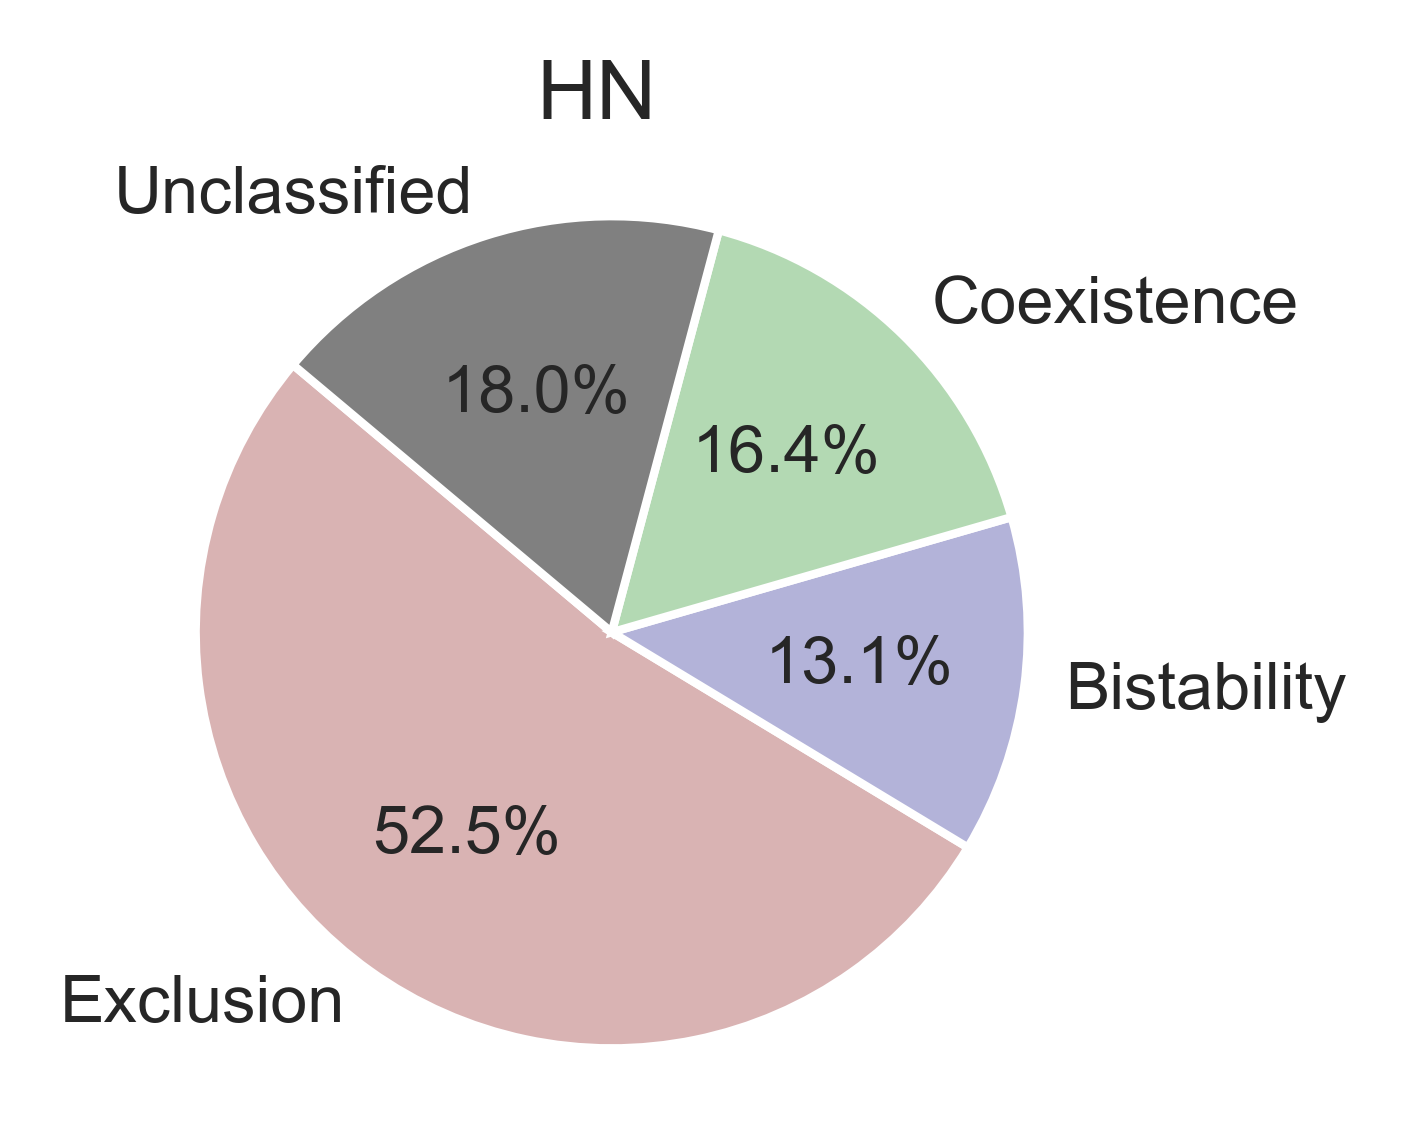

In [24]:

medium_type='HN'

data_m=np.mean(Mono_Count_data[medium_type],1)
data_p_1=Pairwise_Count_data[medium_type][0,:]
data_p_2=Pairwise_Count_data[medium_type][1,:]
data_flag=np.array([[None] * 12]*12)
data_p_1_converted=np.array([[None] * 12]*12)
data_p_2_converted=np.array([[None] * 12]*12)
data_p_ratio=np.array([[None] * 12]*12)

count=0
for i in range(12):
    for j in range(12):
        if np.isnan(data_p_1[i,j]):
            data_flag[i,j]='case0' # No data
        else:
            if data_p_1[i,j]==1 and data_p_2[i,j]==0 :
                #print(i,j,'case1') # species i dominates
                data_flag[i,j]='case1'
                data_p_1_converted[i,j]=1
                data_p_2_converted[i,j]=0
                data_p_ratio[i,j]=1

            elif data_p_1[i,j]==0 and data_p_2[i,j]==1 :
                #print(i,j,'case2') # species j dominates
                data_flag[i,j]='case2'
                data_p_1_converted[i,j]=0
                data_p_2_converted[i,j]=1
                data_p_ratio[i,j]=0
                
            else:
                #print(i,j,'case3') # species i, j coexists
                data_flag[i,j]='case3'
                data_p_1_converted[i,j]=data_p_1[i,j]/data_m[i]
                data_p_2_converted[i,j]=data_p_2[i,j]/data_m[j]
                data_p_ratio[i,j]=data_p_1_converted[i,j]/(data_p_1_converted[i,j]+data_p_2_converted[i,j])
                

def drawPairwiseChange(i, j, x):
    # This is just a sample function. Replace this with your function.
    return np.sin(i*x) + np.cos(j*x)

def InterpretPairwiseResult(y1,y2):
    if y1==1 and y2==1:
        return 'E',(0.85, 0.7, 0.7) #E : competitive exclusion
    elif y1==0 and y2==0:
        return 'E',(0.85, 0.7, 0.7) #E : competitive exclusion
    elif y1==0 and y2==1:
        return 'B',(0.7, 0.7, 0.9) #B : Bistability
    elif y1>0 and y1<1 and y2>0 and y2<1:
        return 'C',(0.7, 0.85, 0.7) #C : Coexistence
    else:
        return 'U',(0.5, 0.5, 0.5) #U : Unclassified

N=12
fig, axs = plt.subplots(N, N, figsize=(250*mm,250*mm))

case_list=[];
for i in range(12):
    for j in range(12):
        if j<=i:
            axs[i,j].spines['top'].set_visible(False)
            axs[i,j].spines['right'].set_visible(False)
            axs[i,j].spines['bottom'].set_visible(False)
            axs[i,j].spines['left'].set_visible(False)
            axs[i,j].get_xaxis().set_ticks([])
            axs[i,j].get_yaxis().set_ticks([])
        elif data_flag[i,j]=='case0':
            axs[i,j].spines['top'].set_visible(False)
            axs[i,j].spines['right'].set_visible(False)
            axs[i,j].spines['bottom'].set_visible(False)
            axs[i,j].spines['left'].set_visible(False)
            axs[i,j].get_xaxis().set_ticks([])
            axs[i,j].get_yaxis().set_ticks([])
        else:    
            x1=[0,1]
            y1=[0.05,data_p_ratio[i,j]]
            axs[i, j].plot(x1, y1)
            x2=[0,1]
            y2=[0.95,1-data_p_ratio[j,i]]
            axs[i, j].plot(x2, y2)
            
            axs[i, j].set_ylim(0,1)
            
            case,shade = InterpretPairwiseResult(y1[1],y2[1])
            case_list.append(case)
            axs[i, j].set_facecolor(shade)
            #axs[i, j].patch.set_alpha(0.5)
            
            axs[i, j].set_title(f'i, j={i+1},{j+1}')
        # Other subplot-specific formatting goes here

# Optional: Improve layout spacing
fig.suptitle(medium_type,fontsize=18)
plt.tight_layout()
plt.show()
fig.savefig('Figure/Fig_3-2_PairwiseInteraction_Matrixplot_'+str(medium_type)+'.svg', bbox_inches='tight')


fig, axs = plt.subplots(1, figsize=(50*mm,50*mm))

E_count = case_list.count('E')
B_count = case_list.count('B')
C_count = case_list.count('C')
U_count = case_list.count('U')

total_count=len(case_list)
E_percentage = (E_count / total_count) * 100
B_percentage = (B_count / total_count) * 100
C_percentage = (C_count / total_count) * 100
U_percentage = (U_count / total_count) * 100

# Create the pie chart
labels = ['Exclusion', 'Bistability', 'Coexistence', 'Unclassified']
sizes = [E_percentage, B_percentage, C_percentage, U_percentage]
colors  = [(0.85, 0.7, 0.7), (0.7,  0.7, 0.85), (0.7, 0.85, 0.7), (0.5, 0.5, 0.5)]
explode = (0, 0, 0, 0)  # explode the 1st slice (E) for emphasis

plt.pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%', colors=colors, startangle=140)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
fig.suptitle(medium_type,fontsize=10)
plt.show()
fig.savefig('Figure/Fig_3-2_PairwiseInteraction_Pieplot_'+str(medium_type)+'.svg', bbox_inches='tight')


In [25]:

graph_edges_pos=[]
graph_edges_neg=[]
graph_edges_bi=[]


for i in range(12):
    for j in range(12):
        if j<=i:
            continue
        elif data_flag[i,j]=='case0':
            continue
        else:    
            x1=[0,1]
            y1=[0.05,data_p_ratio[i,j]]
            x2=[0,1]
            y2=[0.95,1-data_p_ratio[j,i]]
            
            case,shade = InterpretPairwiseResult(y1[1],y2[1])
            if case=='B' :
                graph_edges_bi.append((i,j))
            elif case =='C':
                graph_edges_pos.append((i,j))
            elif case =='E':
                if data_p_ratio[i,j]>0:
                    graph_edges_neg.append((i,j))
                elif data_p_ratio[i,j]==0:
                    graph_edges_neg.append((j,i))
            

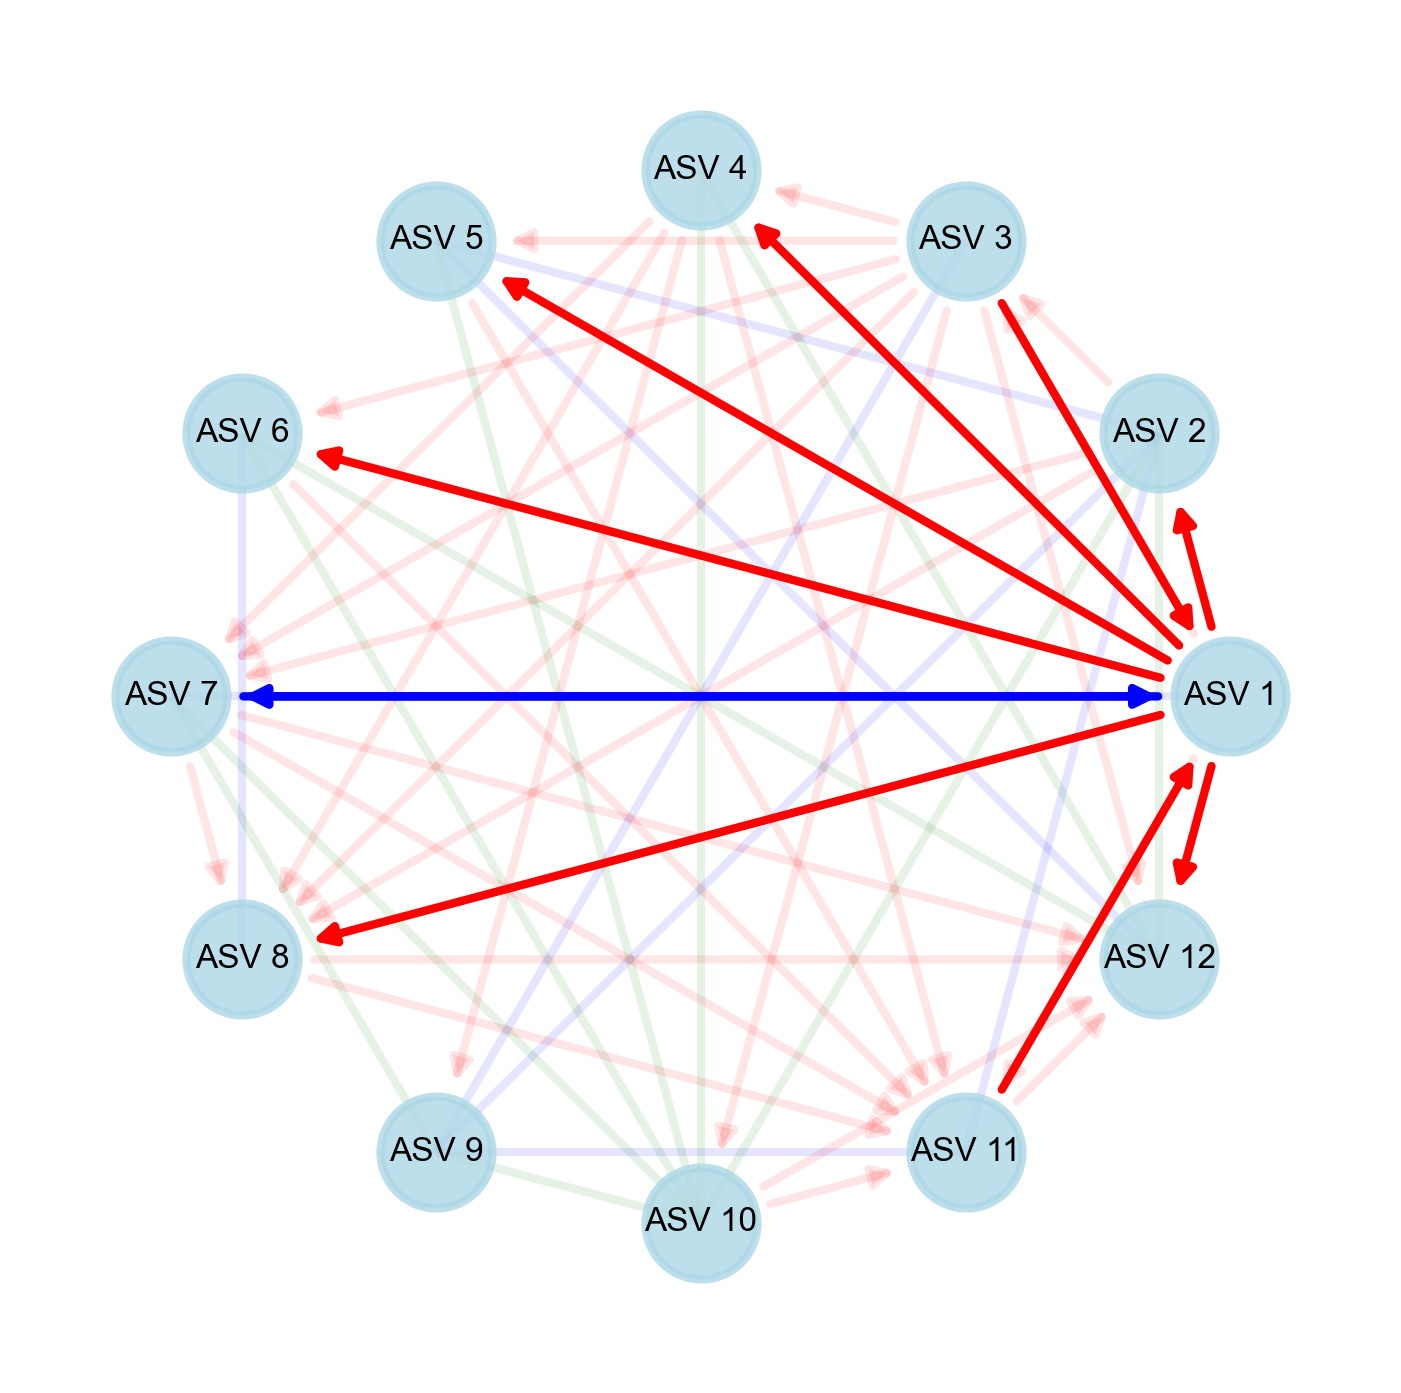

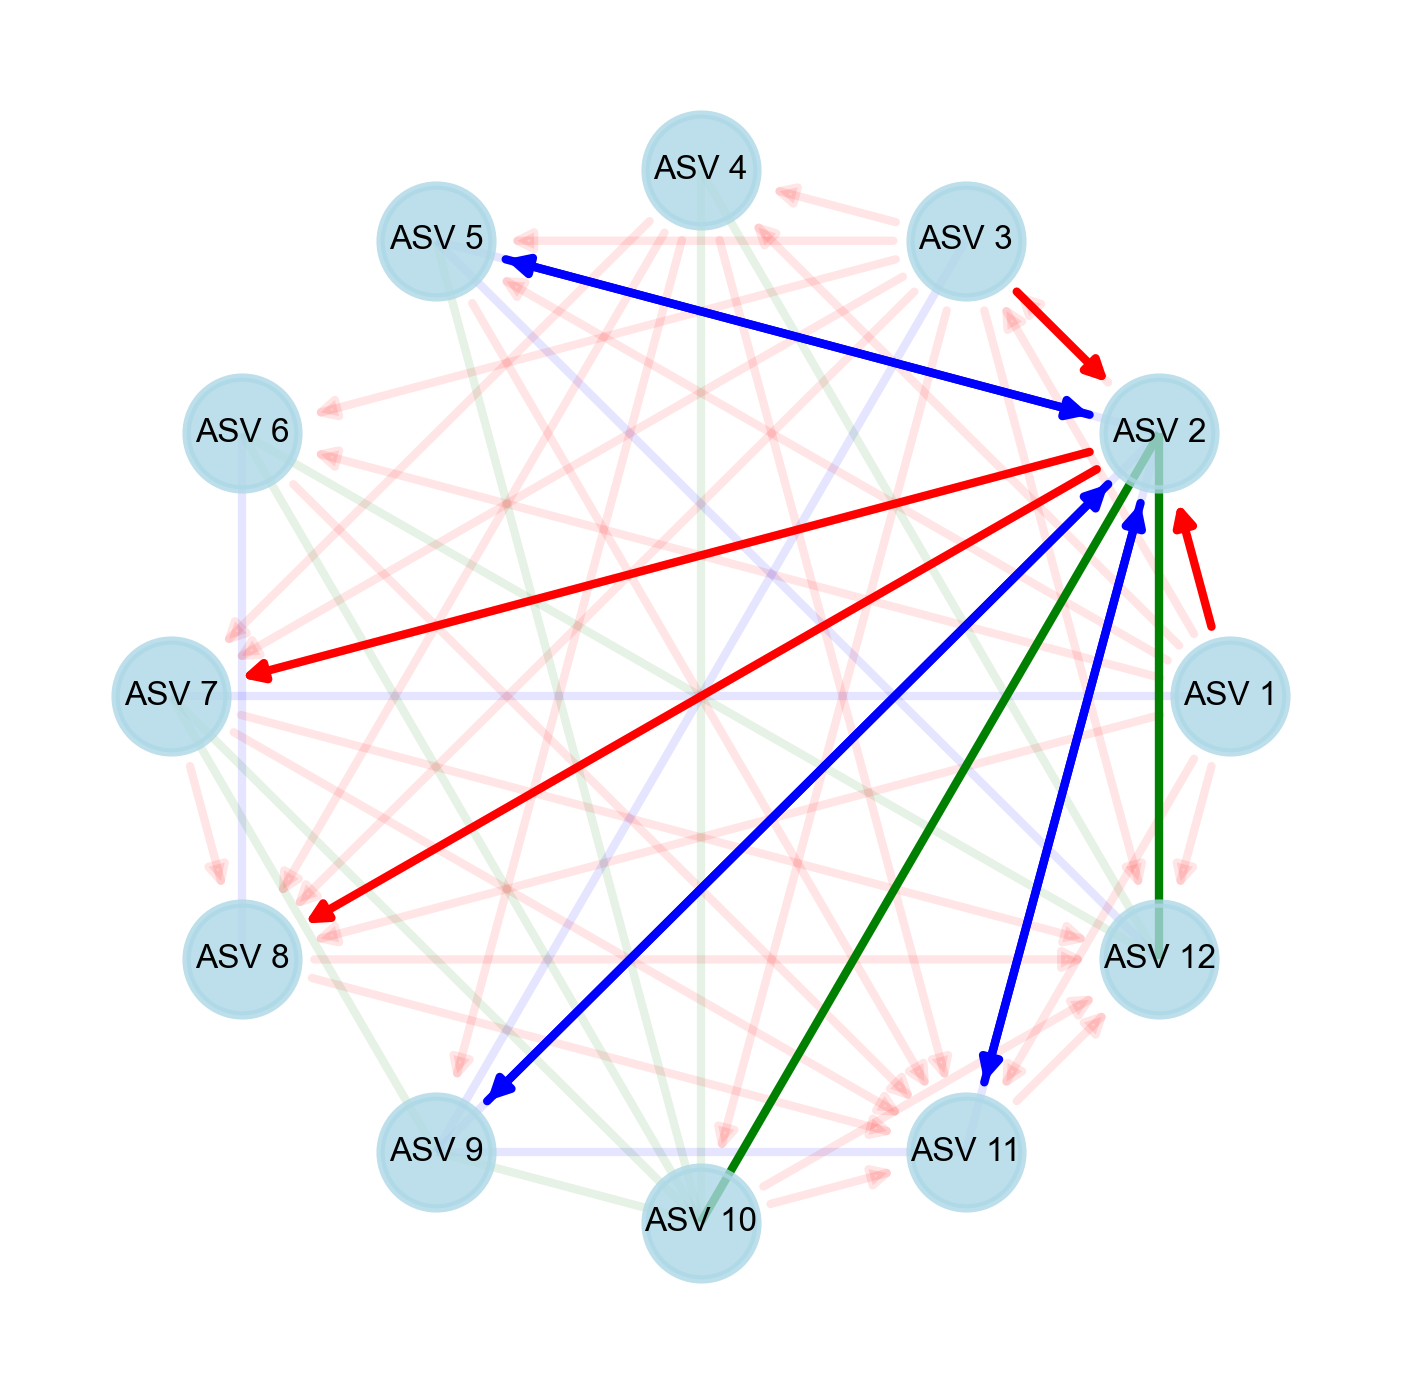

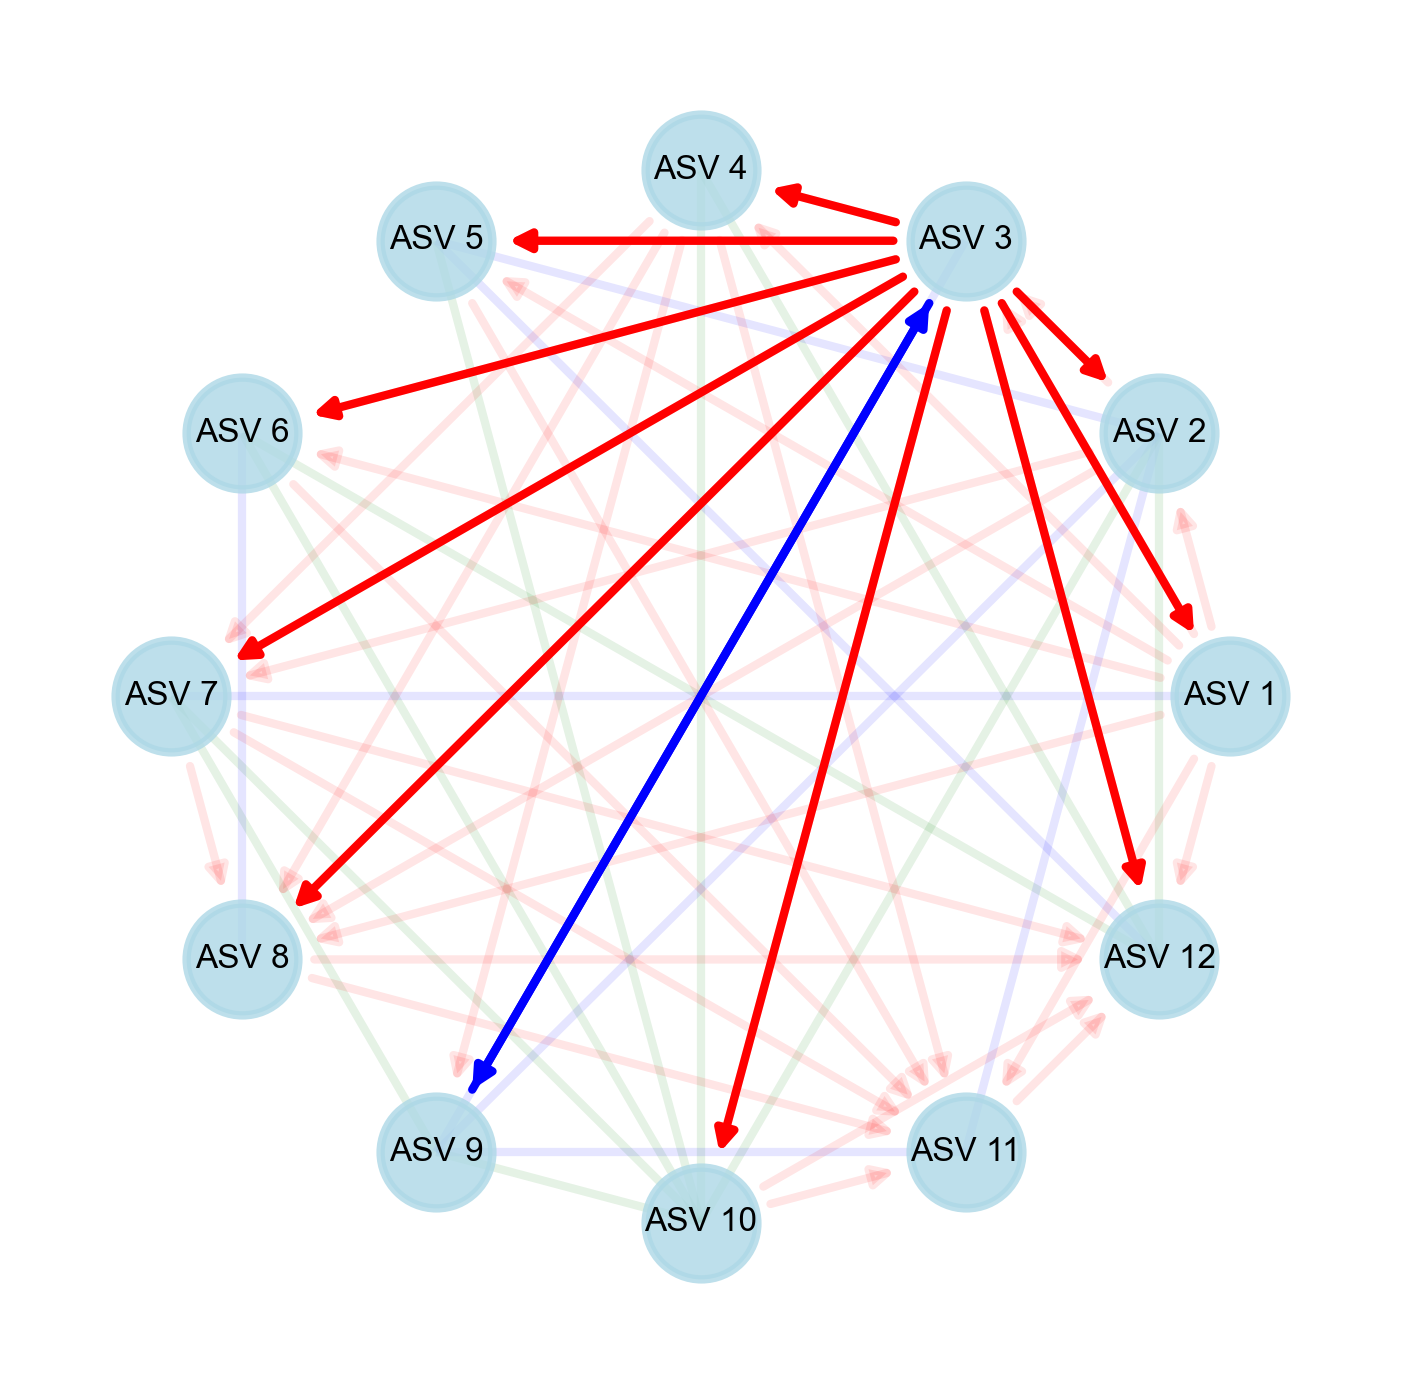

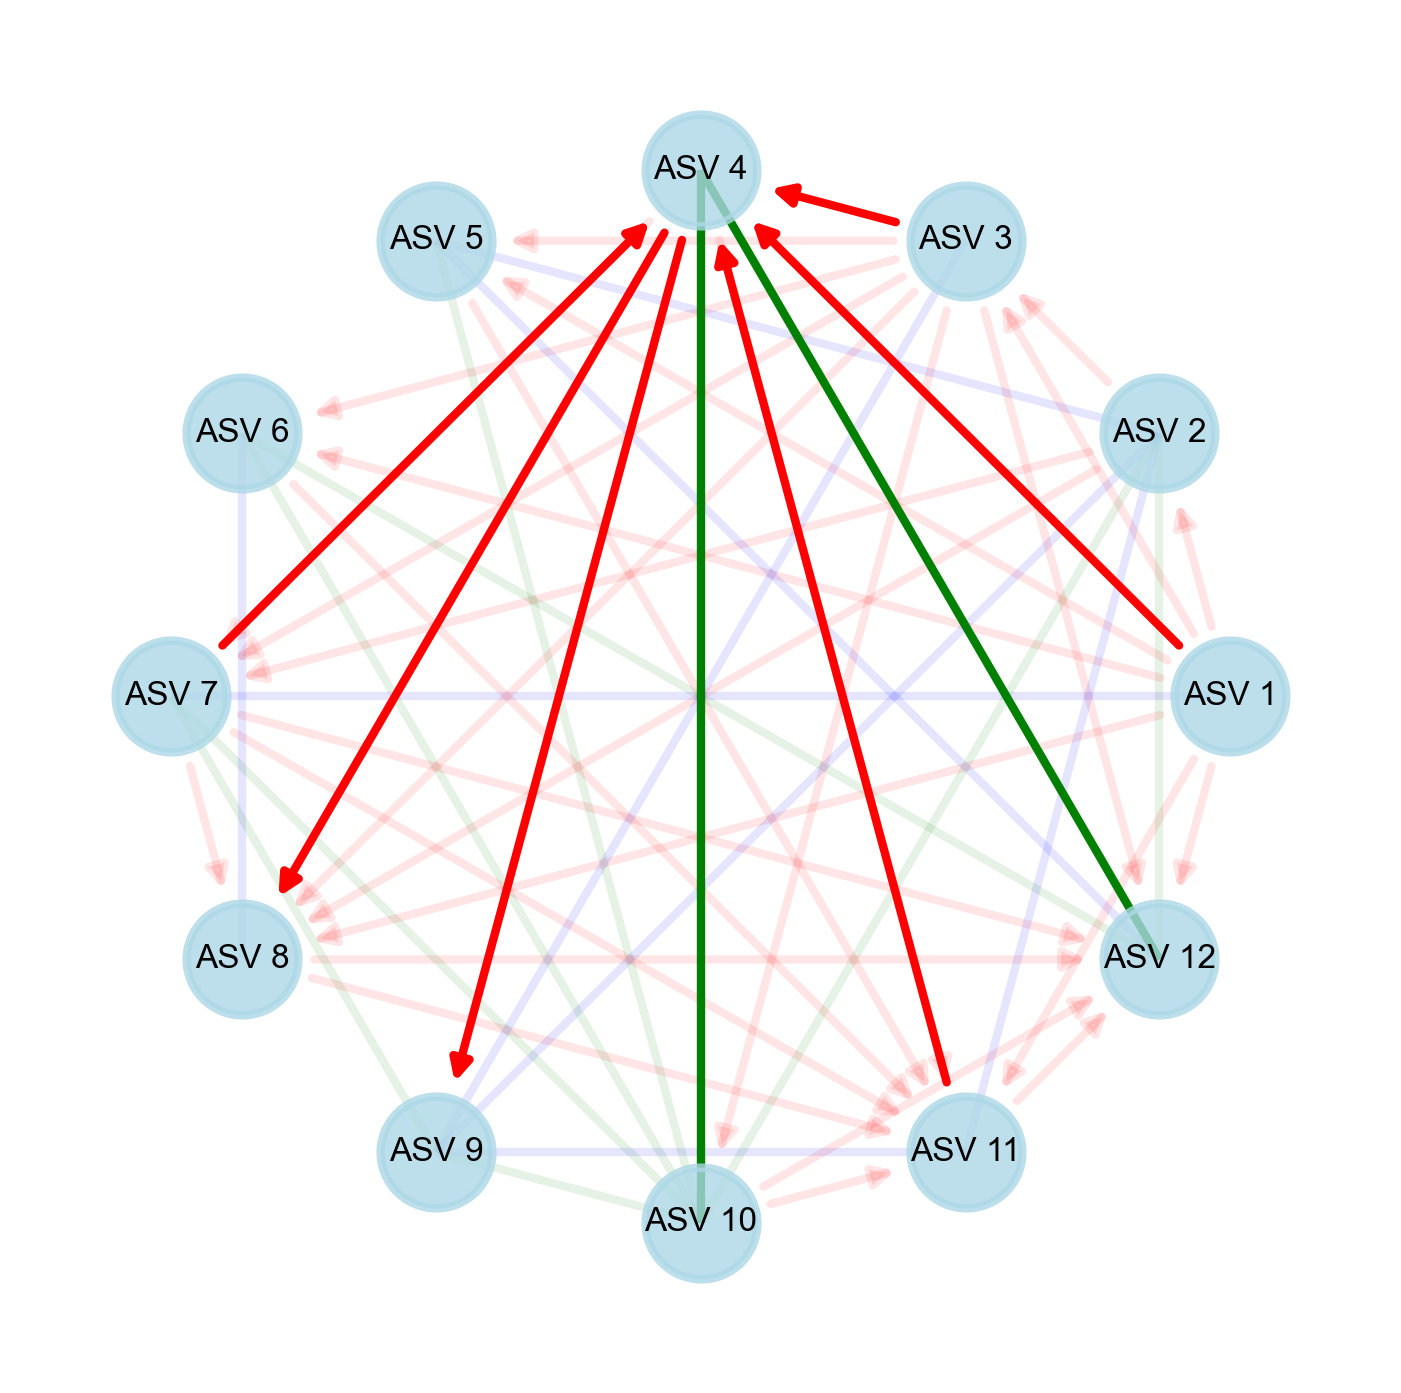

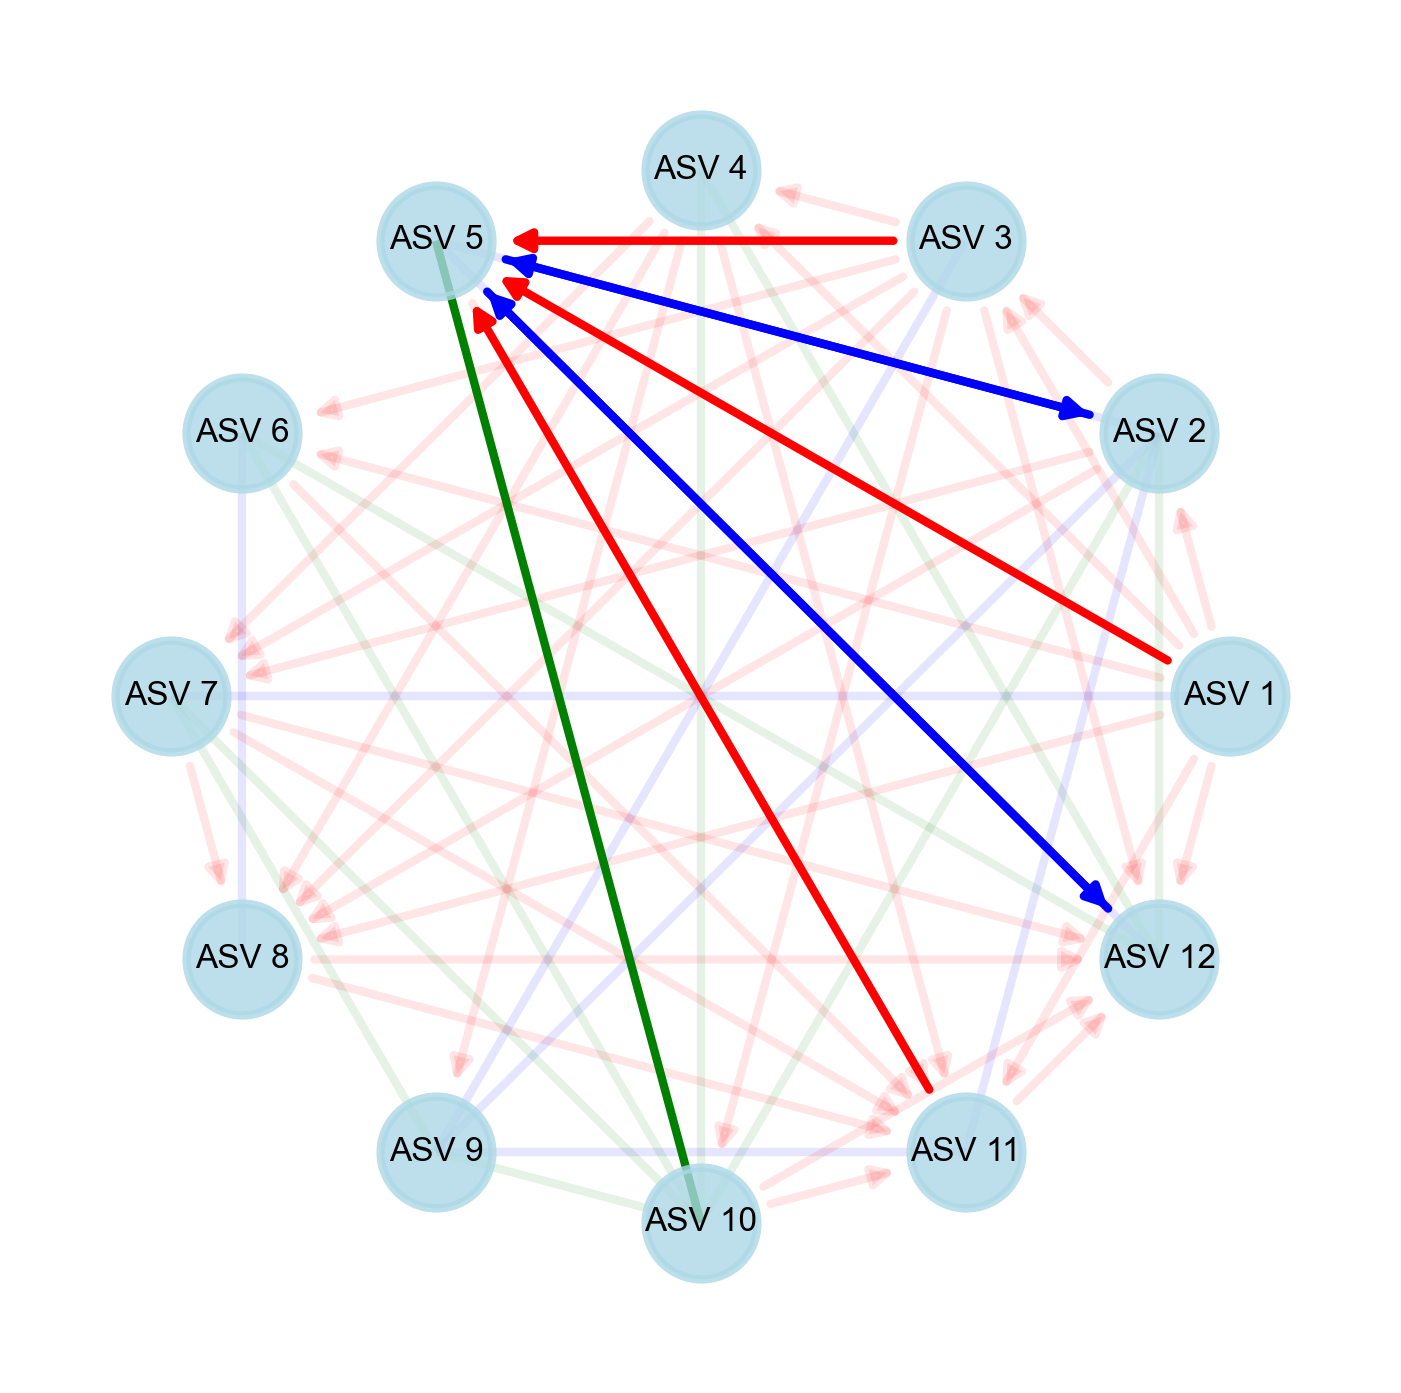

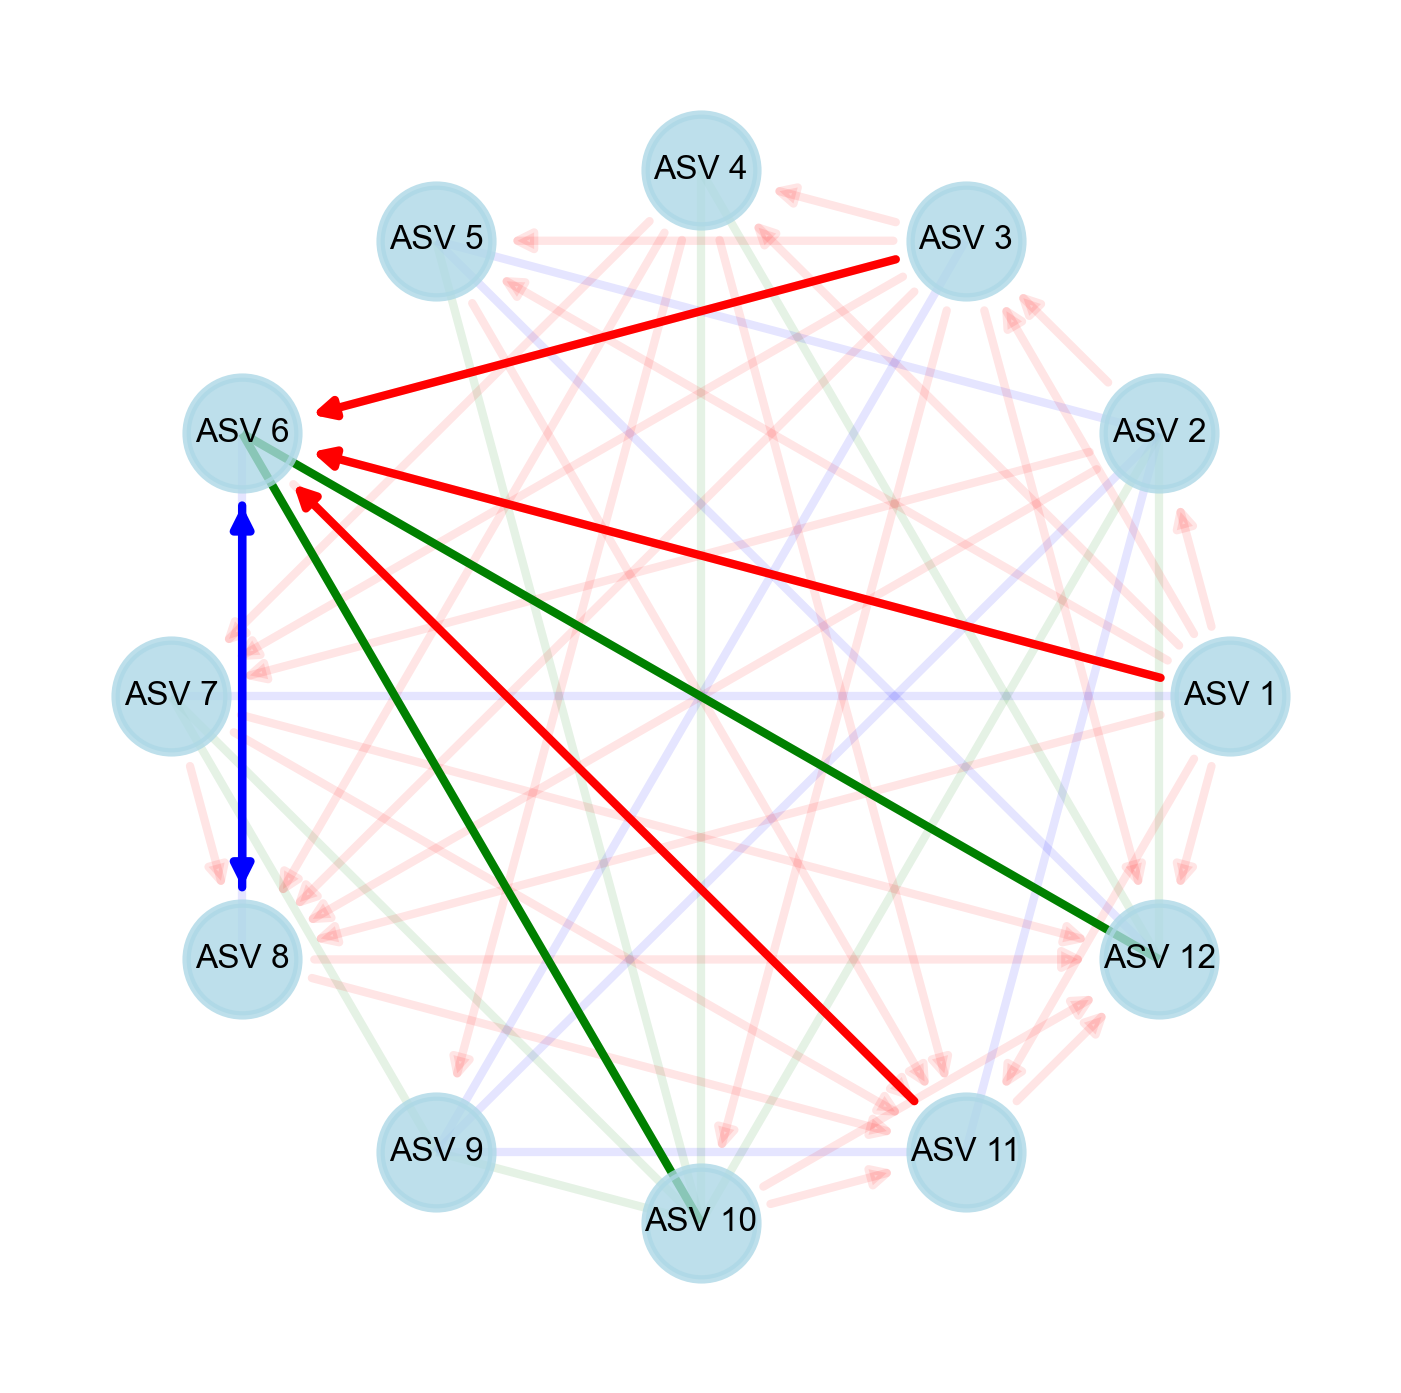

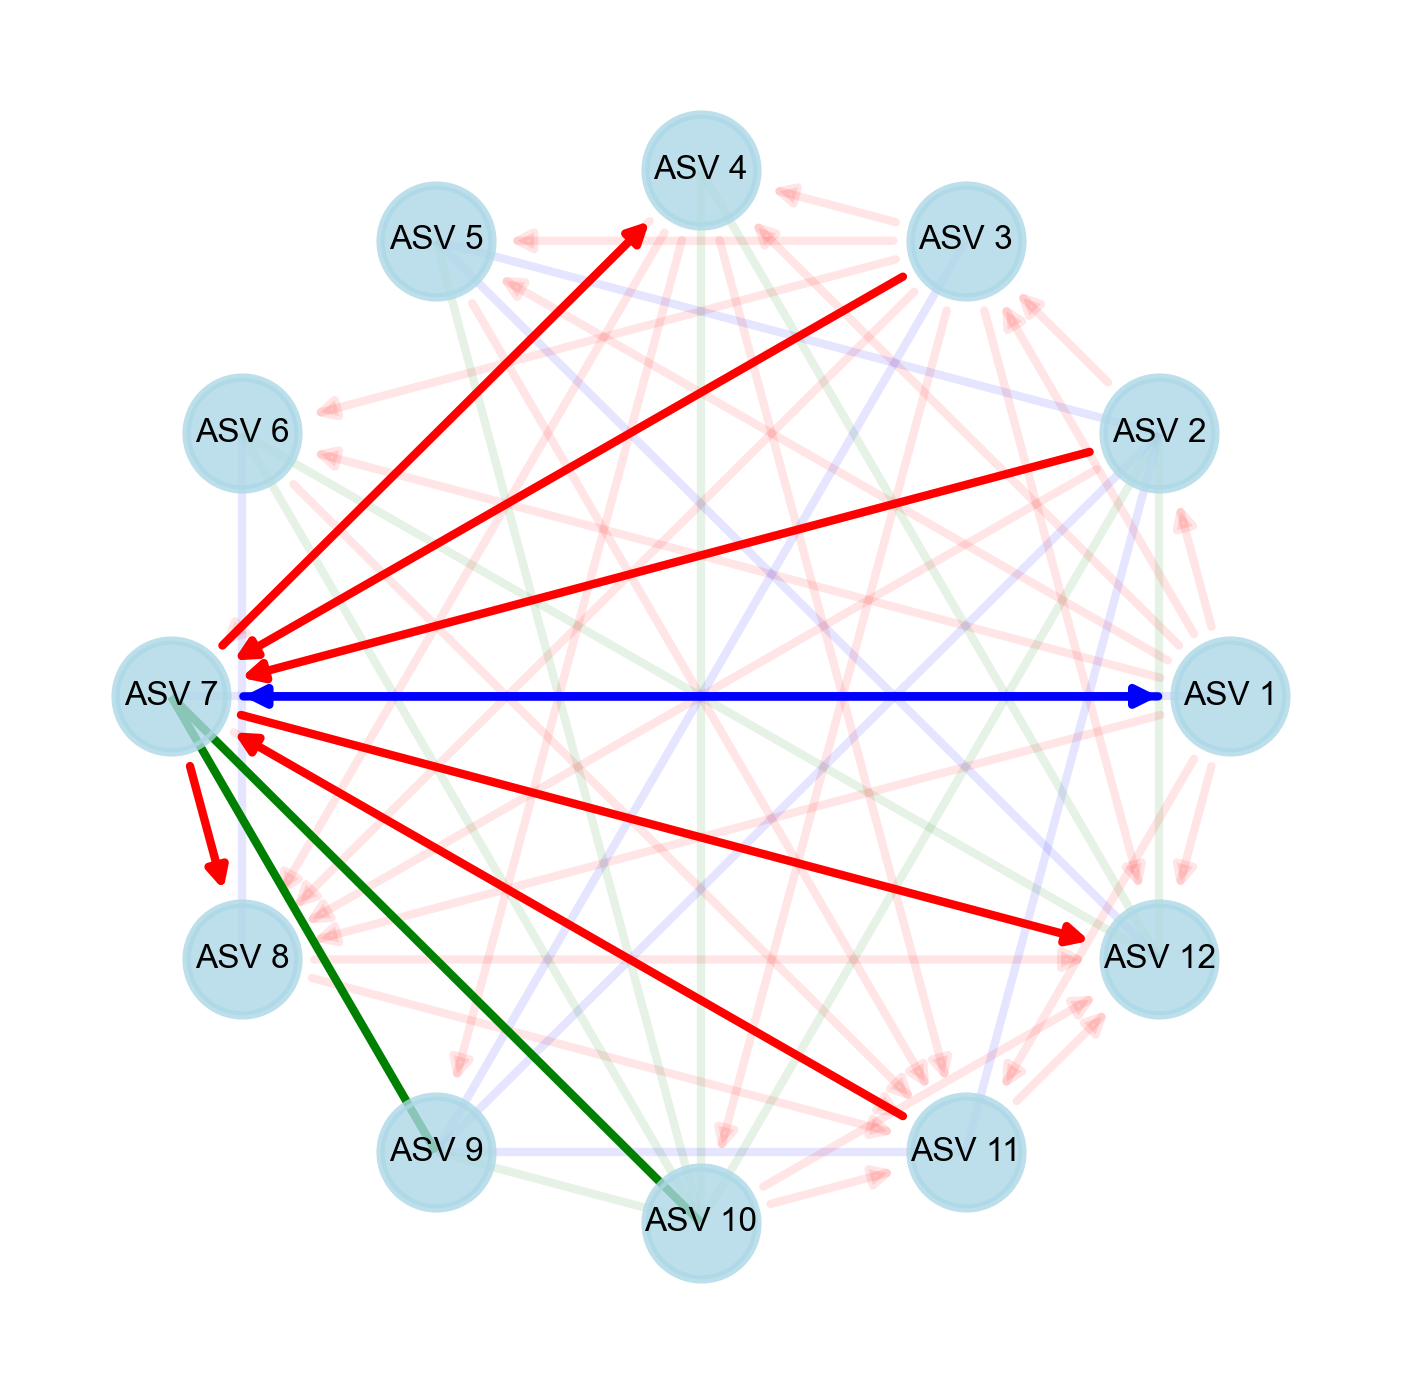

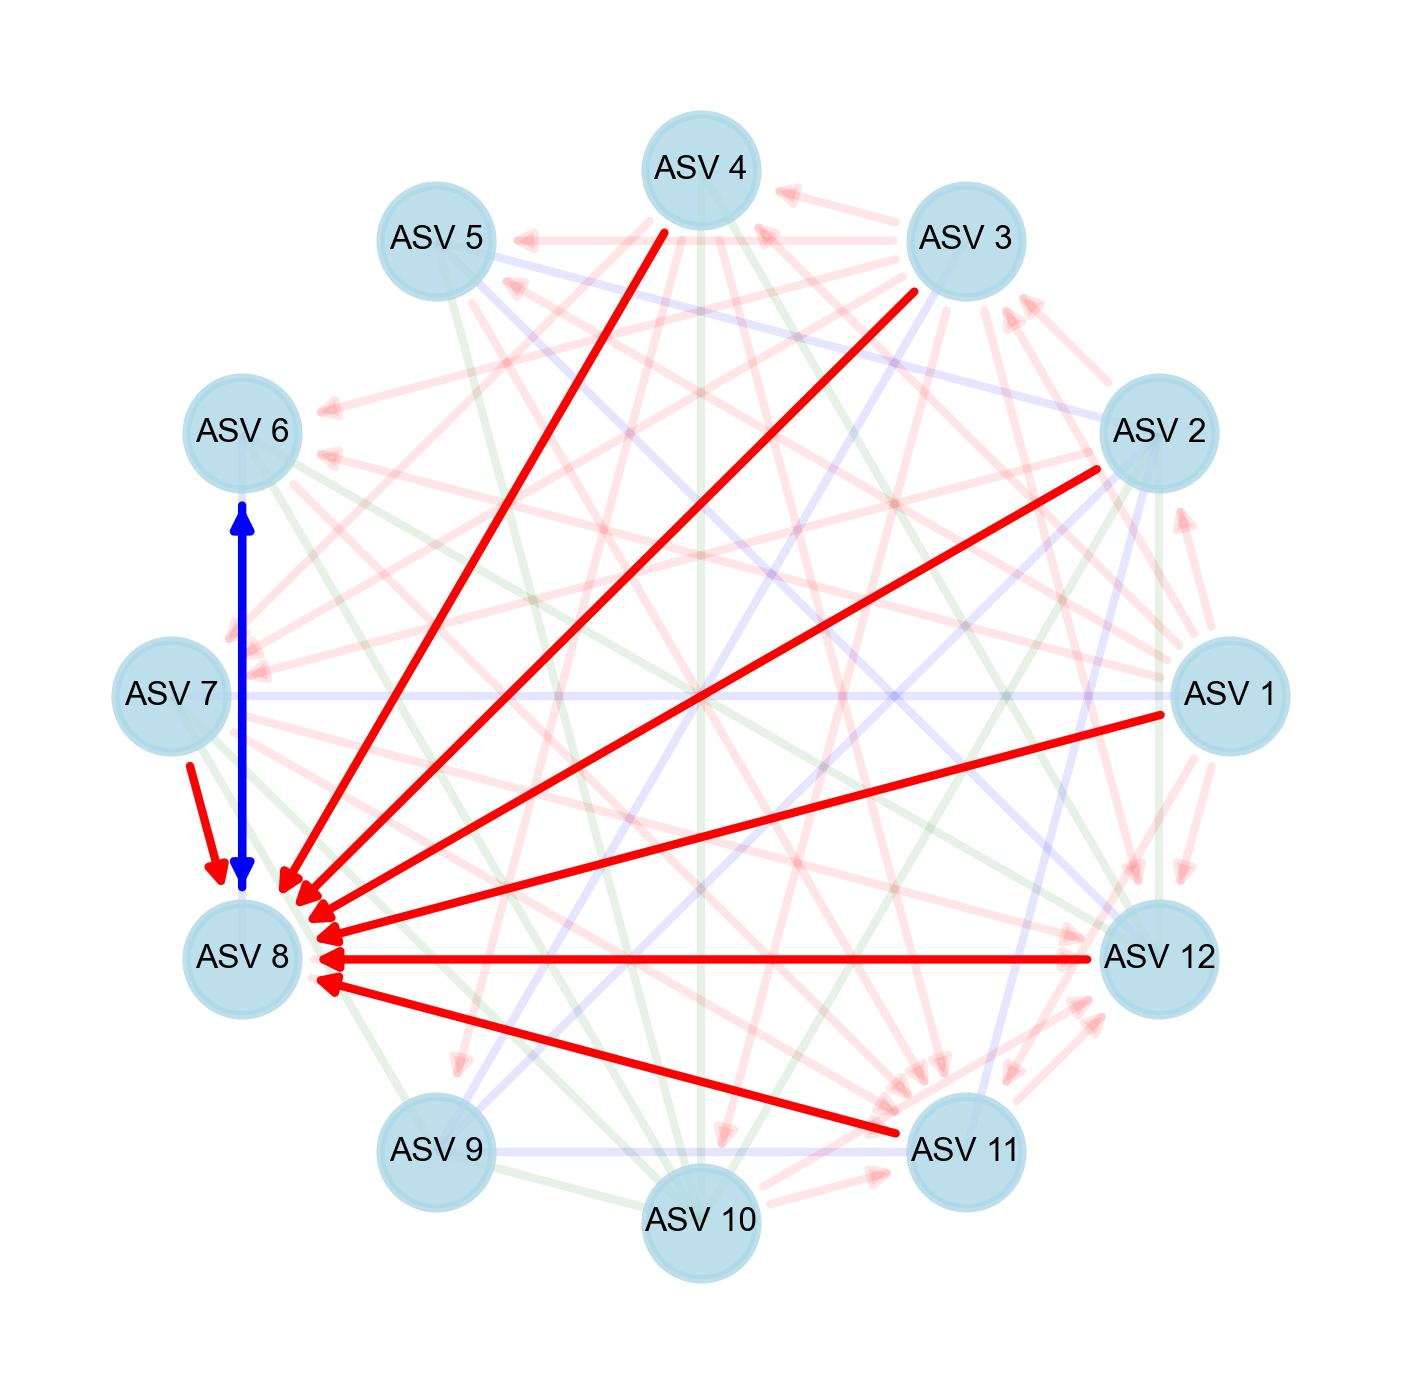

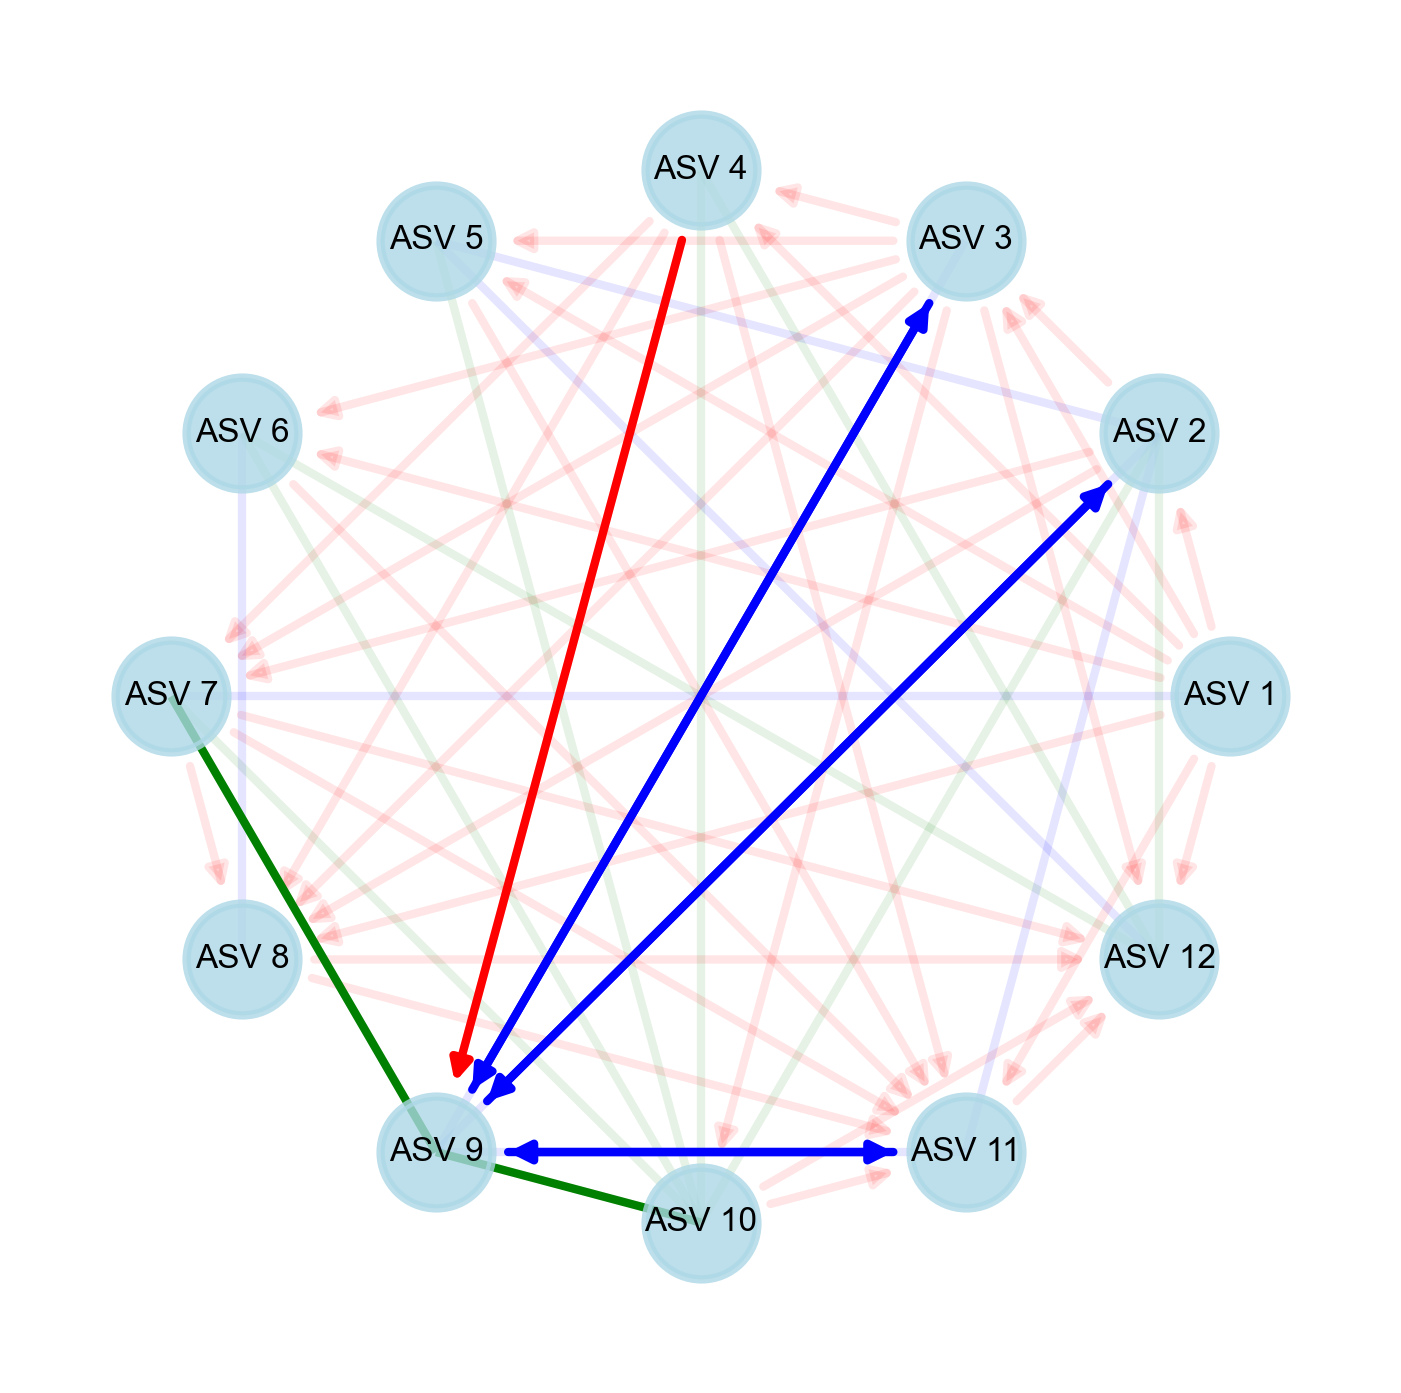

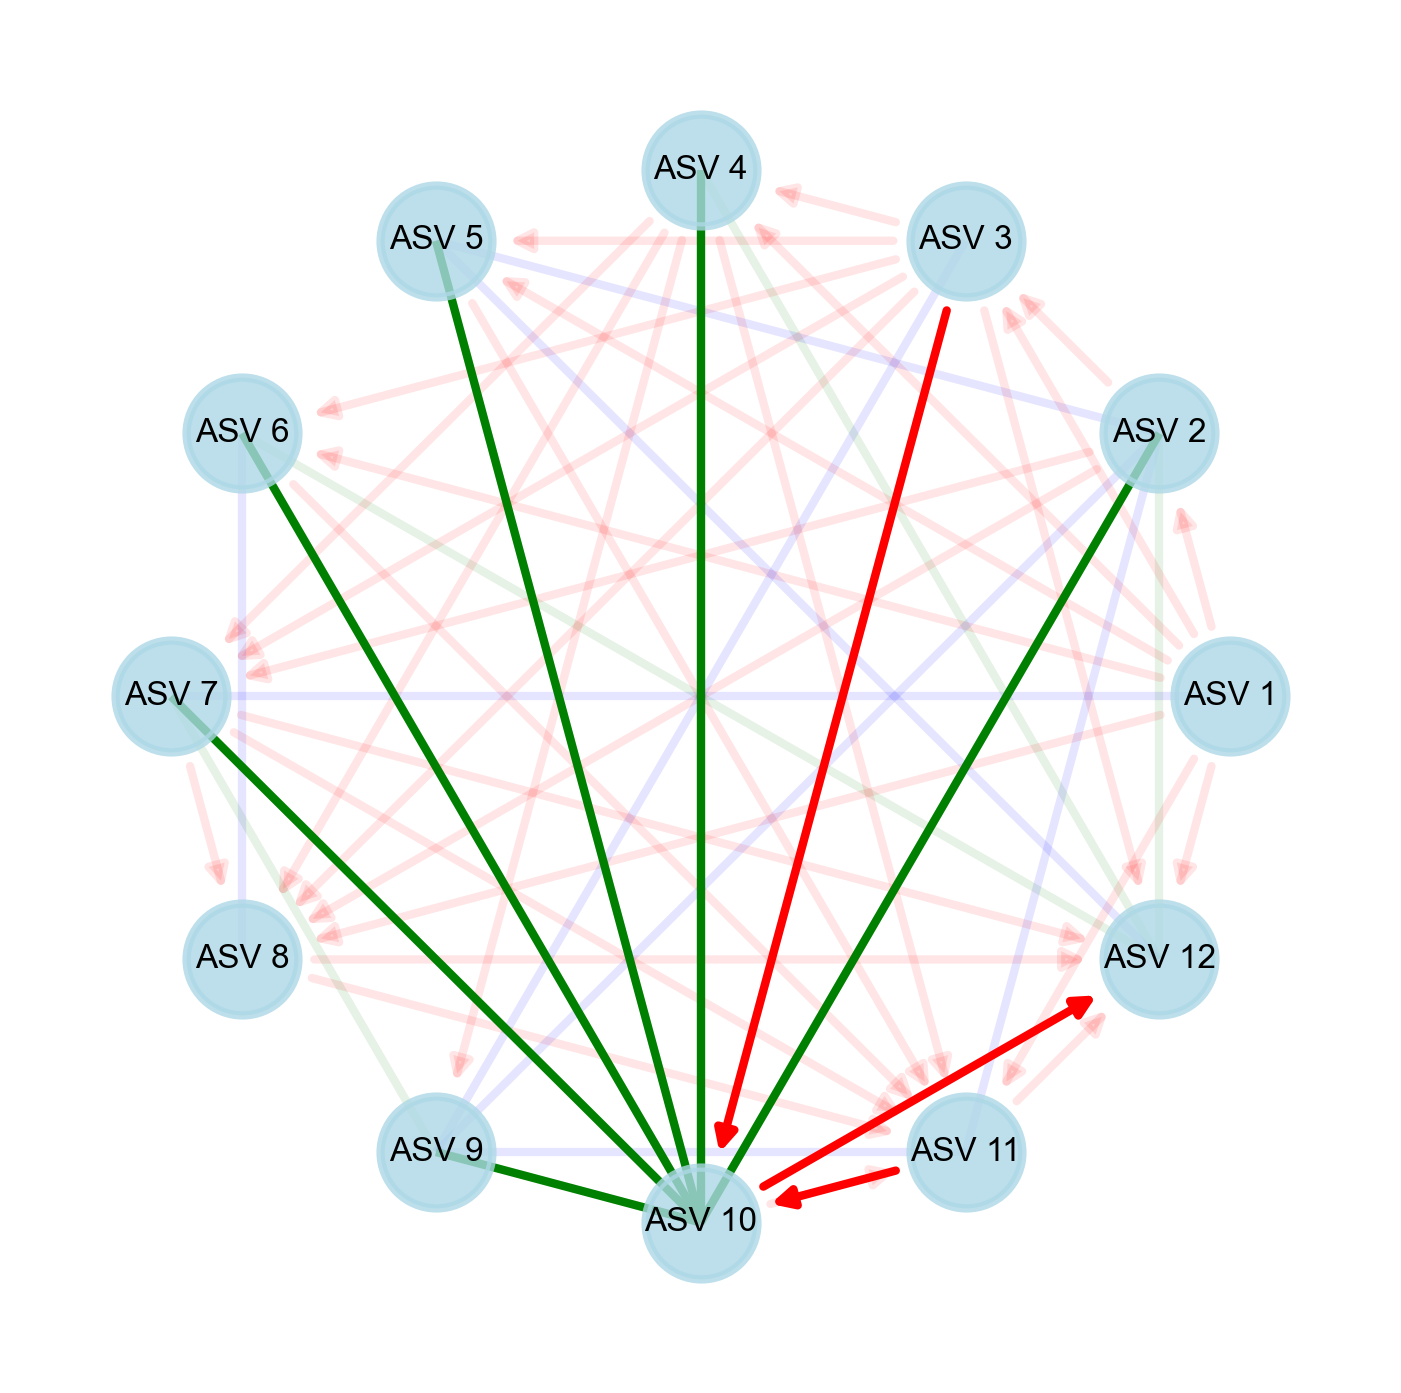

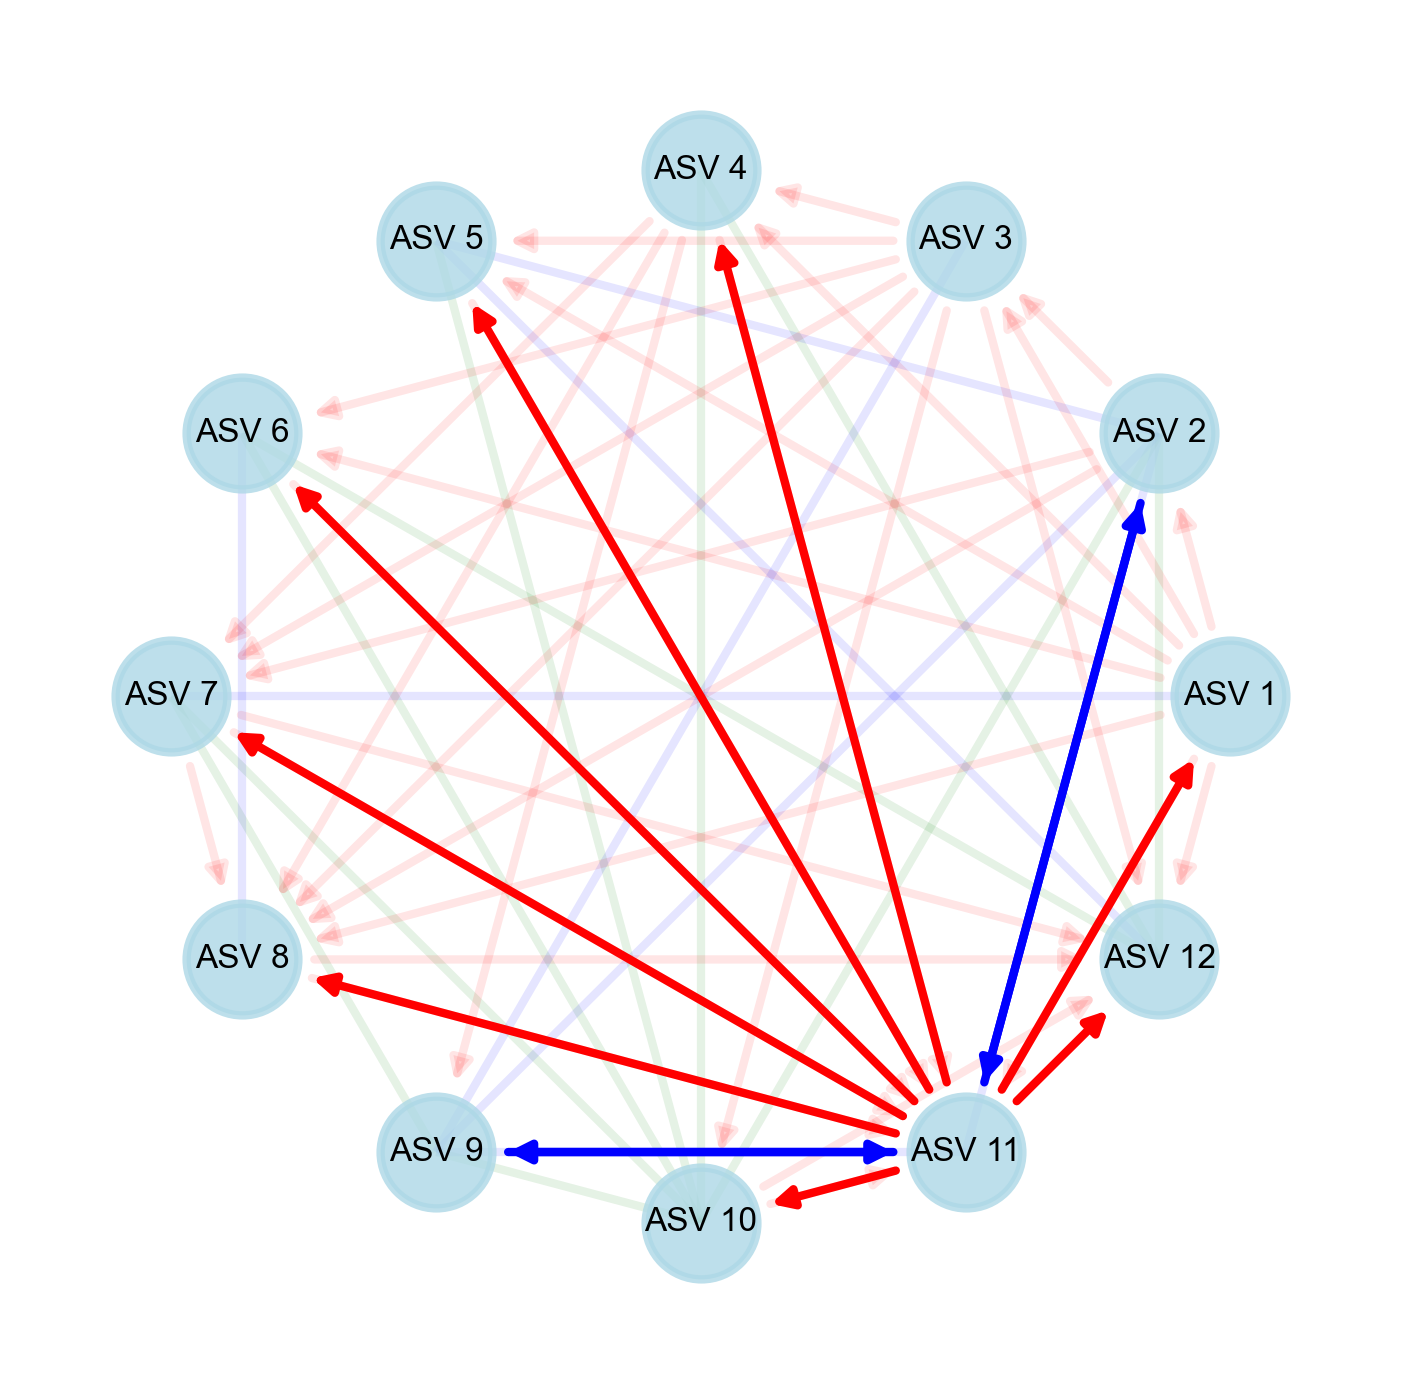

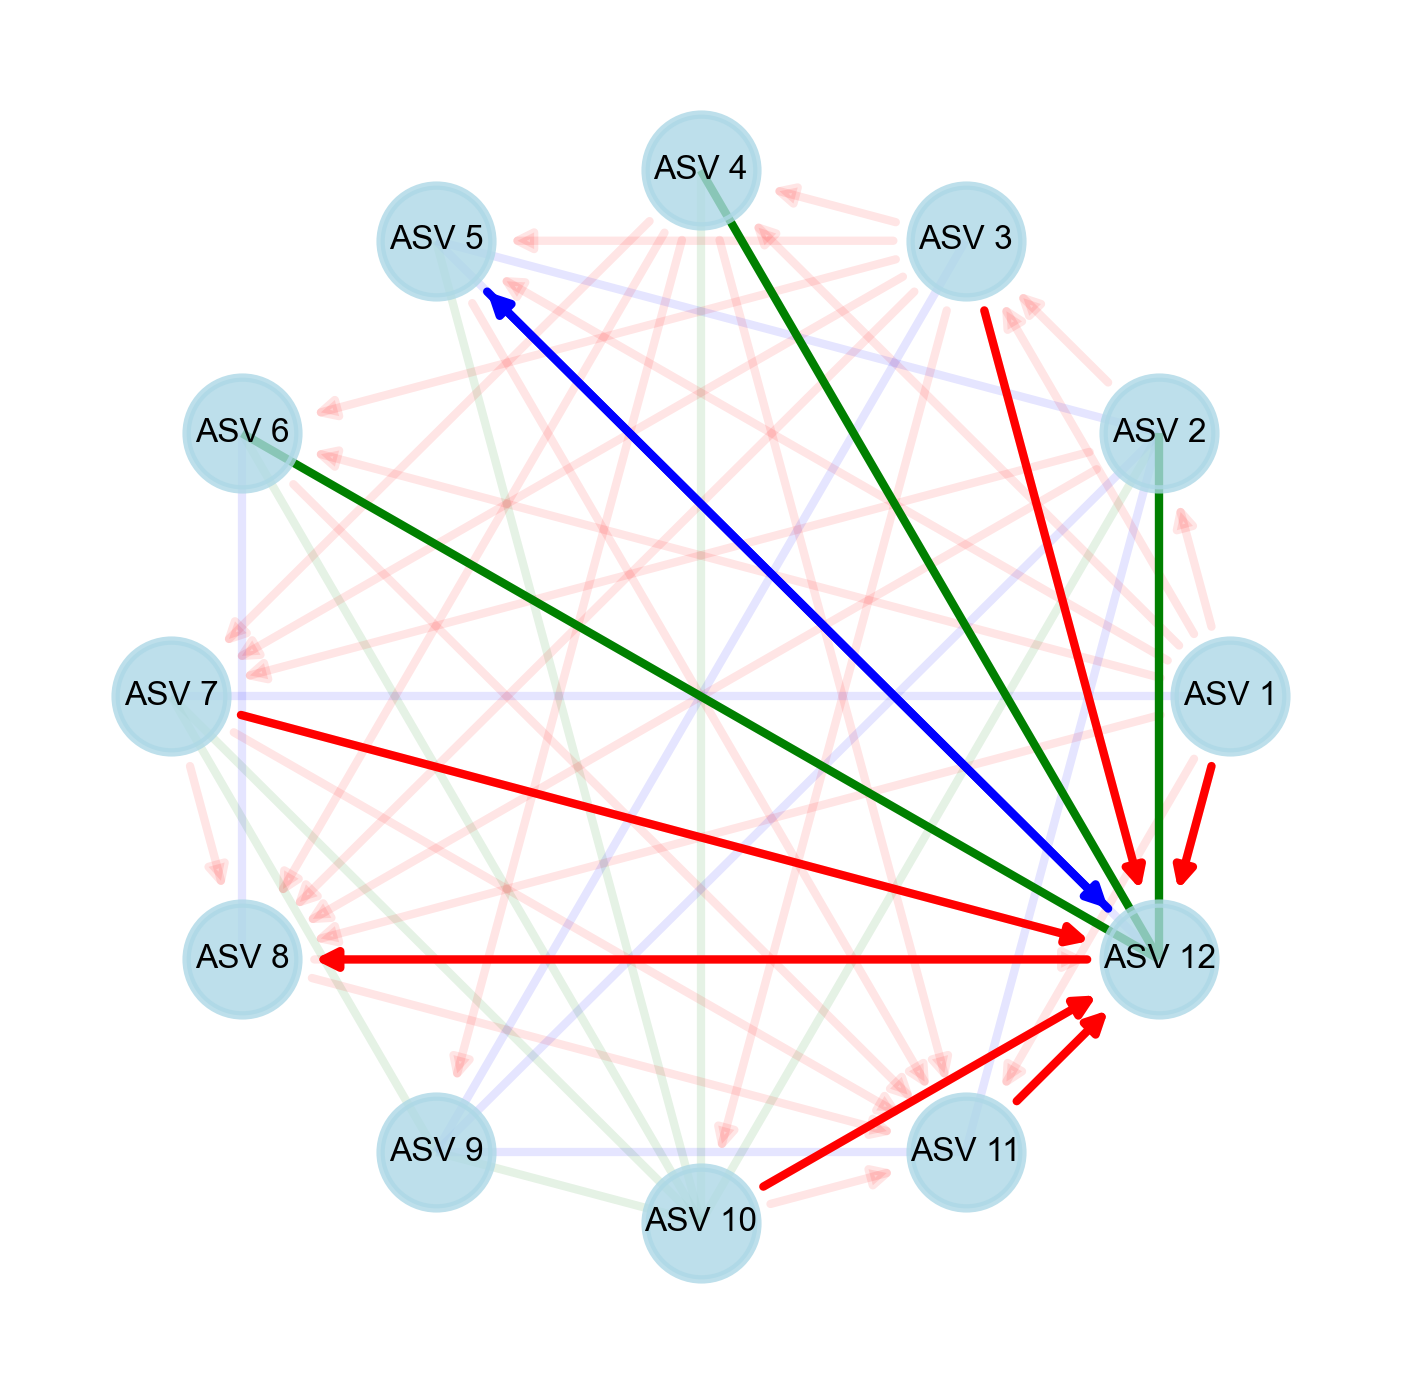

In [26]:
import networkx as nx


for highlight_idx in range(1,13):
    fig, axs = plt.subplots(1, figsize=(70*mm,70*mm))

    # Create an empty graph
    G = nx.Graph()

    # Add 12 nodes
    num_nodes = 12 # 3, 5, 11


    for i in range(num_nodes):
        G.add_node(i)

    # Define your positive and negative edges

    # Add edges to the graph
    G.add_edges_from(graph_edges_pos, sign='positive')
    G.add_edges_from(graph_edges_neg, sign='negative')
    G.add_edges_from(graph_edges_bi, sign='bistability')


    pos = nx.circular_layout(G)


    # Separate edges based on their sign
    positive_edges = [(u, v) for u, v, d in G.edges(data=True) if d['sign'] == 'positive']
    negative_edges = [(u, v) for u, v, d in G.edges(data=True) if d['sign'] == 'negative']
    bistability_edges = [(u, v) for u, v, d in G.edges(data=True) if d['sign'] == 'bistability']

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_size=180, node_color='lightblue', alpha=0.8)

    # Draw positive edges in green and negative edges in red
    nx.draw_networkx_edges(G, pos, edgelist=positive_edges, edge_color='green', width=1, alpha=0.1,  arrows=False, arrowsize=5)
    nx.draw_networkx_edges(G, pos, edgelist=negative_edges, edge_color='red', width=1, alpha=0.1,arrows=True, arrowsize=5)
    nx.draw_networkx_edges(G, pos, edgelist=bistability_edges, edge_color='blue', width=1, alpha=0.1,arrows=False, arrowsize=5)

    for i, edge in enumerate([graph_edges_pos,graph_edges_neg,graph_edges_bi]):
        highlighted_edges = [(u, v) for u, v in edge if u == highlight_idx-1 or v == highlight_idx-1]
        c=['green', 'red', 'blue']
        arrow_set=[False, True, True]
        if i==2:
            nx.draw_networkx_edges(G, pos, edgelist=highlighted_edges, edge_color=c[i], width=1, arrows=arrow_set[i], arrowsize=5)
            nx.draw_networkx_edges(G, pos, edgelist=[(b,a) for (a,b) in (highlighted_edges)], edge_color=c[i], width=1, arrows=arrow_set[i], arrowsize=5)

        else : 
            nx.draw_networkx_edges(G, pos, edgelist=highlighted_edges, edge_color=c[i], width=1, arrows=arrow_set[i], arrowsize=5)


    # Add labels to nodes (optional)
    labels = {i:f'ASV {i + 1}' for i in range(num_nodes)}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=4)

    # Remove axis
    plt.axis('off')

    # Show the plot
    #plt.title("Network Diagram with Circular Layout")

    fig.savefig(f'Figure/network/Fig_5-2_PairwiseInteraction_NetworkPlot_{medium_type}_highlightAT_{highlight_idx}.svg', bbox_inches='tight')



In [13]:
highlighted_edges, [(b,a) for (a,b) in (highlighted_edges)]

([], [])